# Detección de patrones de anomalías térmicas en el Caribe usando datos ERA5 y análisis estadístico multivariable: Analisis Exploratorio

## importacion de librerias

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.signal import periodogram
from scipy.stats import shapiro, boxcox, norm
from scipy.signal import periodogram
from statsmodels.tsa.stattools import adfuller, acf, pacf, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import cartopy.crs as ccrs                            
import cartopy.feature as cfeature
from pymannkendall import original_test as mk_test

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Funciones 

In [3]:
def plot_series_brutas(df, variables, titulo_grupo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1:
        axes = [axes]
    
    for ax, var in zip(axes, variables):
        ax.plot(df.index, df[var], linewidth=0.7, color="steelblue")
        
        # Línea de tendencia lineal encima
        x_num = np.arange(len(df))
        slope, intercept, r, p, _ = stats.linregress(x_num, df[var].values)
        tendencia = slope * x_num + intercept
        ax.plot(df.index, tendencia, color="red", linewidth=1.2,
                linestyle="--", label=f"tendencia (p={p:.3f})")
        
        ax.set_ylabel(var, fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="upper right")
    
    fig.suptitle(f"Series temporales brutas — {titulo_grupo}", fontsize=13)
    axes[-1].set_xlabel("Tiempo")
    plt.tight_layout()
    plt.show()

In [4]:
def calcular_anomalias(df):
    """Resta la media mensual climatológica a cada observación."""
    clim_mensual = df.groupby(df.index.month).mean()
    anomalias = df.copy()
    for mes in range(1, 13):
        mask = df.index.month == mes
        anomalias.loc[mask] = df.loc[mask] - clim_mensual.loc[mes]
    return anomalias

In [5]:
def plot_anomalias(df_anom, variables, titulo_grupo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1:
        axes = [axes]
    
    for ax, var in zip(axes, variables):
        vals = df_anom[var].values
        colores = np.where(vals >= 0, "tomato", "steelblue")
        
        # Bar plot: rojo = anomalía positiva, azul = negativa
        ax.bar(df_anom.index, vals, color=colores, width=20, linewidth=0)
        ax.axhline(0, color="black", linewidth=0.8)
        
        # Media móvil 12 meses para señal interanual
        mm12 = df_anom[var].rolling(12, center=True).mean()
        ax.plot(df_anom.index, mm12, color="black",
                linewidth=1.5, label="media móvil 12 m")
        
        ax.set_ylabel(var, fontsize=9)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper right")
    
    fig.suptitle(f"Anomalías respecto a climatología mensual — {titulo_grupo}", fontsize=13)
    axes[-1].set_xlabel("Tiempo")
    plt.tight_layout()
    plt.show()

In [6]:
def plot_ciclo_estacional(df, variables, titulo_grupo,meses_nombres):
    n = len(variables)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 3.5*nrows))
    axes = np.array(axes).flatten()
    
    for ax, var in zip(axes, variables):
        por_mes = df.groupby(df.index.month)[var]
        media   = por_mes.mean()
        std     = por_mes.std()
        
        ax.fill_between(range(1, 13),
                        media - std, media + std,
                        alpha=0.25, color="steelblue", label="±1σ")
        ax.plot(range(1, 13), media,
                marker="o", color="steelblue", linewidth=2, label="media")
        
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(meses_nombres, fontsize=8)
        ax.set_title(var)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    
    for ax in axes[n:]:
        ax.axis("off")
    
    fig.suptitle(f"Ciclo estacional con ±1σ — {titulo_grupo}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [7]:
def boxplot_mensual(df, var):
    plt.figure(figsize=(10,4))
    sns.boxplot(
        x="month",
        y=var,
        data=df,
        showfliers=False
    )
    plt.title(f"Distribución mensual de {var}")
    plt.xlabel("Mes")
    plt.ylabel(var)
    plt.grid(alpha=0.3)
    plt.show()

In [8]:
def boxplots_grupo(df, variables, titulo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        sns.boxplot(
            x="month",
            y=var,
            data=df,
            showfliers=False,
            ax=ax
        )
        ax.set_title(var)
        ax.grid(alpha=0.3)

    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

## Cargado de datos

In [9]:
ds = xr.open_dataset("era5_caribe_mensual_1976_2025_UNIFICADO.nc")
print(ds)

<xarray.Dataset> Size: 877MB
Dimensions:    (step: 12, latitude: 73, longitude: 65, time: 600)
Coordinates:
    number     int64 8B ...
  * step       (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    surface    float64 8B ...
  * latitude   (latitude) float64 584B 13.0 12.75 12.5 12.25 ... -4.5 -4.75 -5.0
  * longitude  (longitude) float64 520B -82.0 -81.75 -81.5 ... -66.25 -66.0
  * time       (time) datetime64[ns] 5kB 1976-01-01 1976-02-01 ... 2025-12-01
Data variables:
    u10        (time, latitude, longitude) float32 11MB ...
    v10        (time, latitude, longitude) float32 11MB ...
    t2m        (time, latitude, longitude) float32 11MB ...
    e          (time, step, latitude, longitude) float32 137MB ...
    msl        (time, latitude, longitude) float32 11MB ...
    sst        (time, latitude, longitude) float32 11MB ...
    slhf       (time, step, latitude, longitude) float32 137MB ...
    ssr        (time, step, latitude, longitude) float32 137MB ...
    ssrd 

**DICCIONARIO DE LAS VARIABLES**



    '10m_u_component_of_wind':          {'short_name': 'u10',  'alias': 'u10'},

    '10m_v_component_of_wind':          {'short_name': 'v10',  'alias': 'v10'},

    '2m_temperature':                    {'short_name': 't2m',  'alias': 't2m'},

    'evaporation':                       {'short_name': 'e',    'alias': 'e'},

    'mean_sea_level_pressure':           {'short_name': 'msl',  'alias': 'msl'},

    'sea_surface_temperature':           {'short_name': 'sst',  'alias': 'sst'},

    'surface_latent_heat_flux':          {'short_name': 'slhf', 'alias': 'slhf'},

    'surface_net_solar_radiation':       {'short_name': 'ssr',  'alias': 'ssr'},

    'surface_solar_radiation_downwards': {'short_name': 'ssrd', 'alias': 'ssrd'},

    'surface_thermal_radiation_downwards':{'short_name': 'strd','alias': 'strd'},

    'total_precipitation':               {'short_name': 'tp',   'alias': 'tp'},


**ESTRUCTURA VISIBLE DE LOS DATOS**

Es un dataset climático multidimensional proveniente de Copernicus Climate Change Service (ERA5), con:

- Cobertura temporal: 1976 → 2025 (600 meses)
- Resolución temporal: mensual
- Región: Caribe (incluye parte del norte de Sudamérica)

dimensiones son:

- time (600): tiempo (mensual)
- latitude (73): eje vertical del mapa
- longitude (65): eje horizontal del mapa
- step (12): step representa horizonte temporal dentro del mes

Coordenadas:
- latitude: 13 → -5 : Va de norte a sur (Caribe hacia zona ecuatorial)
- longitude: -82 → -66: Incluye Colombia, Caribe, parte de Centroamérica
- time: 1976-01 → 2025-12 → Serie temporal completa

Variables:

Variables sin **step**:
Estas dependen de:

(time, latitude, longitude)

- t2m → temperatura a 2m (variable objetivo)
- sst → temperatura superficial del mar
- msl → presión a nivel del mar
- u10, v10 → componentes del viento

Variables con **step**:
Estas dependen de:

(time, step, latitude, longitude)

- tp: precipitación
- ssr, ssrd: radiación solar
- strd: radiación térmica
- slhf: flujo de calor latente
- e: evaporación

Tamaño y complejidad:
- 877 MB
- Variables con step dominan el tamaño(computacional)

Variable Objetivo:

- Temperatura 2m (temperatura superficial)

**COSAS IMPORTANTES A NOTAR:**
- 3 Dimensiones:

-- Temporal

-- Espacial

-- Multivariables

- variables con y sin step (a la hora de tratar y analizar)
- La variabilidad es mensual
- Es un dataset local, evitar generalizaciones

## verificaciones iniciales de los datos

### 1. Integridad

**verificacion de valores faltantes**

In [10]:
for var in ds.data_vars:
    missing = ds[var].isnull().sum().item()
    print(f"{var}: {missing} valores faltantes")

u10: 0 valores faltantes
v10: 0 valores faltantes
t2m: 0 valores faltantes
e: 0 valores faltantes
msl: 0 valores faltantes
sst: 2010600 valores faltantes
slhf: 0 valores faltantes
ssr: 0 valores faltantes
ssrd: 0 valores faltantes
strd: 0 valores faltantes
tp: 0 valores faltantes


La variable sst presenta valores faltantes significativos (~2 millones), lo cual es consistente con su naturaleza física, ya que solo está definida sobre superficies oceánicas. No se identifican valores faltantes en las demás variables, lo que indica alta completitud del dataset.

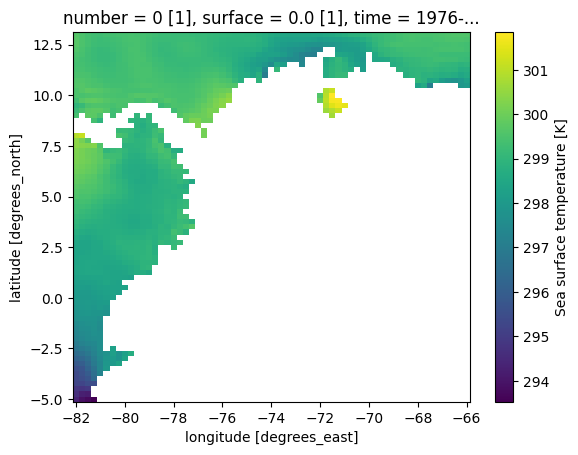

In [11]:
ds['sst'].isel(time=0).plot()

Como se puede ver en la grafica puesto que todo lo que no es mar se considera vacio

**Continuidad temporal**

In [12]:
import pandas as pd

time_diff = pd.Series(ds.time.values).diff().value_counts()
print(time_diff)

31 days    349
30 days    200
28 days     37
29 days     13
Name: count, dtype: int64


Esto es perfecto.

Refleja:

Meses reales del calendario:
- 31 días
- 30 días
- Febrero (28/29)

O sea:

- No hay saltos temporales
- No faltan meses

La serie temporal es continua y consistente con la estructura mensual del calendario, sin evidencia de datos faltantes o discontinuidades.

**Dimensiones consistentes**

In [13]:
for var in ds.data_vars:
    print(var, ds[var].dims)

u10 ('time', 'latitude', 'longitude')
v10 ('time', 'latitude', 'longitude')
t2m ('time', 'latitude', 'longitude')
e ('time', 'step', 'latitude', 'longitude')
msl ('time', 'latitude', 'longitude')
sst ('time', 'latitude', 'longitude')
slhf ('time', 'step', 'latitude', 'longitude')
ssr ('time', 'step', 'latitude', 'longitude')
ssrd ('time', 'step', 'latitude', 'longitude')
strd ('time', 'step', 'latitude', 'longitude')
tp ('time', 'step', 'latitude', 'longitude')


Las dimensiones de las variables son coherentes con su naturaleza física, diferenciando correctamente entre variables instantáneas y variables dependientes del horizonte temporal (step).

**Cobertura espacial completa**

In [14]:
print(ds.latitude.min().item(), ds.latitude.max().item())
print(ds.longitude.min().item(), ds.longitude.max().item())

-5.0 13.0
-82.0 -66.0


Esto coincide exactamente con:

region: Caribe

ademas que no hay cortes ni inconsistencias

**Conclusion integridad**

El dataset presenta una alta integridad estructural. No se identifican valores faltantes en la mayoría de las variables, con excepción de sst, cuyos valores faltantes son consistentes con su definición física (solo sobre océanos). La serie temporal es continua y respeta la periodicidad mensual del calendario. Las dimensiones de las variables son coherentes y la cobertura espacial corresponde correctamente a la región del Caribe sin inconsistencias.

### 2. Exactitud

In [15]:
def check_exactitud(ds):
    
    print("=== VERIFICACIÓN DE EXACTITUD ===")
    
    for var in ds.data_vars:
        data = ds[var]
        
        print(f"\nVariable: {var}")
        
        # Estadísticas básicas
        min_val = float(data.min())
        max_val = float(data.max())
        
        print(f"Min: {min_val}")
        print(f"Max: {max_val}")
        
        # --- Reglas físicas ---
        
        #  Temperatura (Kelvin)
        if var in ['t2m', 'sst']:
            invalid = ((data < 150) | (data > 350)).sum().item()
            print(f"Valores fuera de rango físico (150K - 350K): {invalid}")
        
        #  Precipitación
        elif var == 'tp':
            invalid = (data < 0).sum().item()
            print(f"Valores negativos (inválidos): {invalid}")
        
        #  Viento
        elif var in ['u10', 'v10']:
            invalid = (np.abs(data) > 150).sum().item()
            print(f"Valores extremos (>150 m/s): {invalid}")
        
        #  Presión
        elif var == 'msl':
            invalid = ((data < 80000) | (data > 120000)).sum().item()
            print(f"Valores fuera de rango (80000 - 120000 Pa): {invalid}")
        
        #  Radiación y flujos
        elif var in ['ssr', 'ssrd', 'strd', 'slhf']:
            invalid = (data < 0).sum().item()
            print(f"Valores negativos (posible error): {invalid}")
        
        #  Evaporación
        elif var == 'e':
            # Puede ser negativa (condensación), así que solo extremos
            invalid = (np.abs(data) > 1).sum().item()
            print(f"Valores extremos (>1 m de agua): {invalid}")
        
        else:
            print("No hay regla definida para esta variable")

In [16]:
check_exactitud(ds)

=== VERIFICACIÓN DE EXACTITUD ===

Variable: u10
Min: -12.790410041809082
Max: 7.410929203033447
Valores extremos (>150 m/s): 0

Variable: v10
Min: -9.319337844848633
Max: 8.784035682678223
Valores extremos (>150 m/s): 0

Variable: t2m
Min: 277.9945373535156
Max: 307.7173156738281
Valores fuera de rango físico (150K - 350K): 0

Variable: e
Min: -0.0003844672755803913
Max: 7.191924396465765e-06


Valores extremos (>1 m de agua): 0

Variable: msl
Min: 100633.5703125
Max: 102413.2578125
Valores fuera de rango (80000 - 120000 Pa): 0

Variable: sst
Min: 288.7977600097656
Max: 306.53436279296875
Valores fuera de rango físico (150K - 350K): 0

Variable: slhf
Min: -961469.9375
Max: 17982.09765625
Valores negativos (posible error): 34161568

Variable: ssr
Min: 2649.806396484375
Max: 1787591.75
Valores negativos (posible error): 0

Variable: ssrd
Min: 2883.0966796875
Max: 1852527.5
Valores negativos (posible error): 0

Variable: strd
Min: 911246.4375
Max: 1619786.5
Valores negativos (posible error): 0

Variable: tp
Min: 0.0
Max: 0.007257516961544752
Valores negativos (inválidos): 0


**Conclusion general Exactitud**
Las variables analizadas presentan valores dentro de rangos físicamente plausibles, sin evidencia de errores críticos como valores imposibles o inconsistentes. Las variables de temperatura, presión, viento y precipitación muestran comportamientos coherentes con la región del Caribe. Algunas variables de flujo energético, como slhf, presentan valores negativos debido a convenciones físicas y magnitudes elevadas asociadas a acumulaciones temporales, lo cual no constituye un error sino una característica del dataset.

### 3. Validez

**Tipos de datos**

In [17]:
for var in ds.data_vars:
    print(var, ds[var].dtype)

u10 float32
v10 float32
t2m float32
e float32
msl float32
sst float32
slhf float32
ssr float32
ssrd float32
strd float32
tp float32


Esto es exactamente lo esperado en datos climáticos.

**Coordenadas validas**

In [18]:
print(ds.latitude.values[:5])
print(ds.longitude.values[:5])

[13.   12.75 12.5  12.25 12.  ]
[-82.   -81.75 -81.5  -81.25 -81.  ]


Las coordenadas geográficas son válidas, consistentes y corresponden a una grilla regular sobre la región del Caribe. Se observa un orden descendente en latitud.

**Verificacion del tiempo**

In [19]:
print(ds.time.dtype)

datetime64[ns]


Esto es el estándar ideal en Python

**Conclusion general Validez**

El dataset cumple con los criterios de validez, presentando tipos de datos consistentes (float32) en todas las variables, adecuados para representar magnitudes físicas continuas. Las coordenadas espaciales son válidas y corresponden a una grilla regular dentro de los rangos geográficos esperados. La variable temporal se encuentra en formato datetime64[ns], lo que garantiza compatibilidad con herramientas de análisis temporal y permite realizar operaciones avanzadas sin inconvenientes.

**Conclusion final de la verificacion:**
- Integridad: Alta
- Exactitud: sin errores fisicos
- Validez: Estructura correcta

In [20]:
vars_era5 = list(ds.data_vars)

vars_era5

['u10', 'v10', 't2m', 'e', 'msl', 'sst', 'slhf', 'ssr', 'ssrd', 'strd', 'tp']

In [21]:
vars_no_step = ["t2m", "sst", "msl", "u10", "v10"]
vars_step = ["tp", "ssr", "ssrd", "strd", "slhf", "e"]

In [22]:
ds_step_monthly = ds[vars_step].sum(dim="step", skipna=True)
ds_full = xr.merge([ds[vars_no_step], ds_step_monthly])

In [23]:
ds_ts = ds_full.mean(dim=["latitude", "longitude"], skipna=True)
df_ts = ds_ts.to_dataframe().drop(columns=["number", "surface"], errors="ignore")
df_ts.index = pd.to_datetime(df_ts.index)

In [24]:
tiempo = df_ts.index
df_ts['month'] = df_ts.index.month
todas_vars = list(df_ts.columns)

## Dimension temporal

se realiza el analisis de las variables a nivel temporal, creando graficos temporales como series de tiempo, verificando si se tienen anomalias climaticas y la estacionalidad de las series de cada variable a lo largo del tiempo

### **Series de tiempo**

In [25]:
grupos = {
    "Temperatura": ["t2m", "sst"],
    "Precipitación": ["tp"]
}

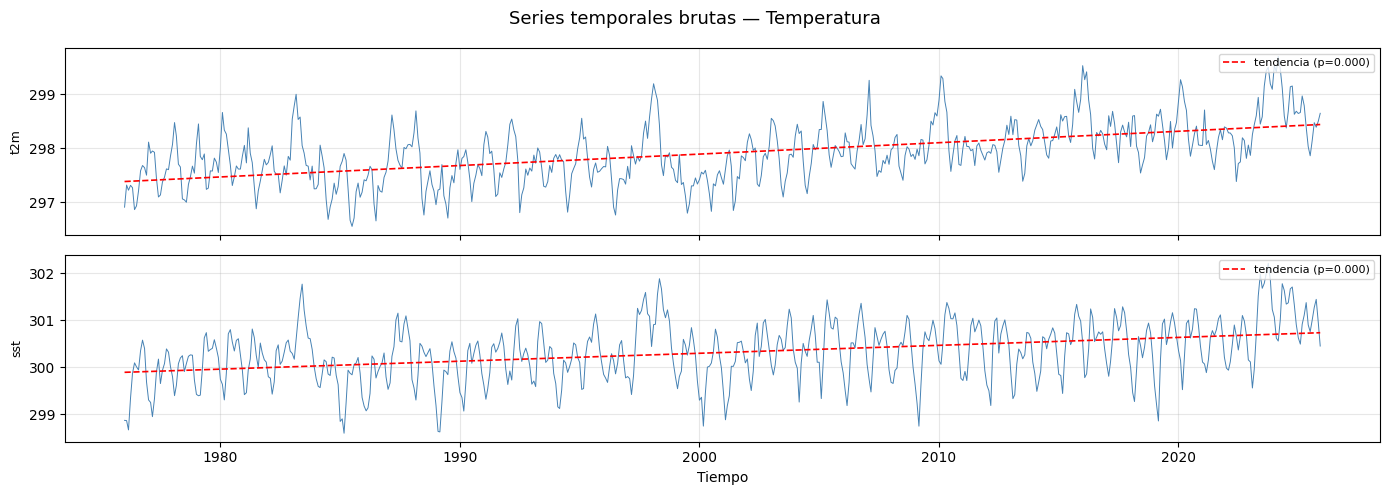

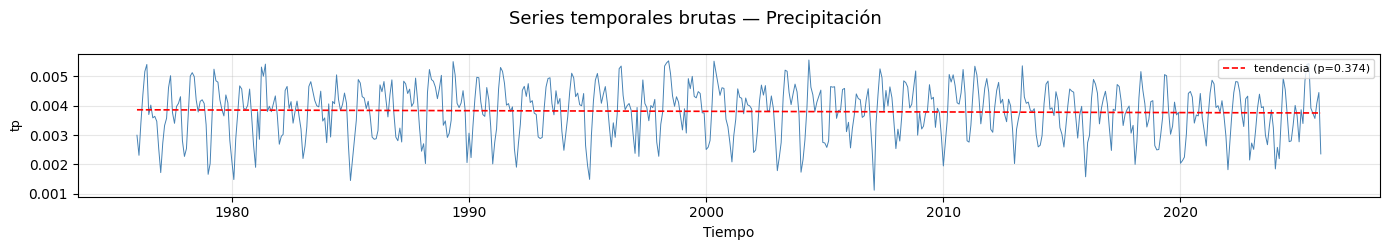

In [26]:
for nombre, vars_g in grupos.items():
    plot_series_brutas(df_ts, vars_g, nombre)

- Las variables de temperatura muestran la señal más robusta de cambio climático en el dataset.

    * **t2m (Temperatura a 2m) y sst (Temperatura superficial del mar):** Ambos indicadores presentan una **tendencia ascendente lineal** con un valor de p extremadamente bajo ($p=0.000$).
    * **Observación:** Se nota un incremento aproximado de 1°C entre el inicio y el final de la serie, con picos de calor cada vez más frecuentes e intensos en la última década (2015-2025).

* **tp (Precipitación total):** A diferencia de las variables térmicas, la precipitación no muestra una señal clara de cambio antropogénico en este dataset.
    * **Tendencia:** Presenta una **estabilidad interanual** con una pendiente prácticamente nula y un valor de p no significativo ($p=0.374$).
    * **Observación:** La serie está dominada por la **variabilidad natural y la estacionalidad**, manteniendo un rango de oscilación constante entre 0.001 y 0.005 unidades a lo largo de los 50 años registrados.
    * **Ciclos Extremos:** Aunque la media es estable, se identifican años con mínimos pluviométricos acentuados (posibles sequías) en periodos específicos como 1980, 2007 y 2021, sin que estos aumenten en frecuencia aparente.

### **Anomalias mensuales**

In [27]:
df_anom = calcular_anomalias(df_ts)

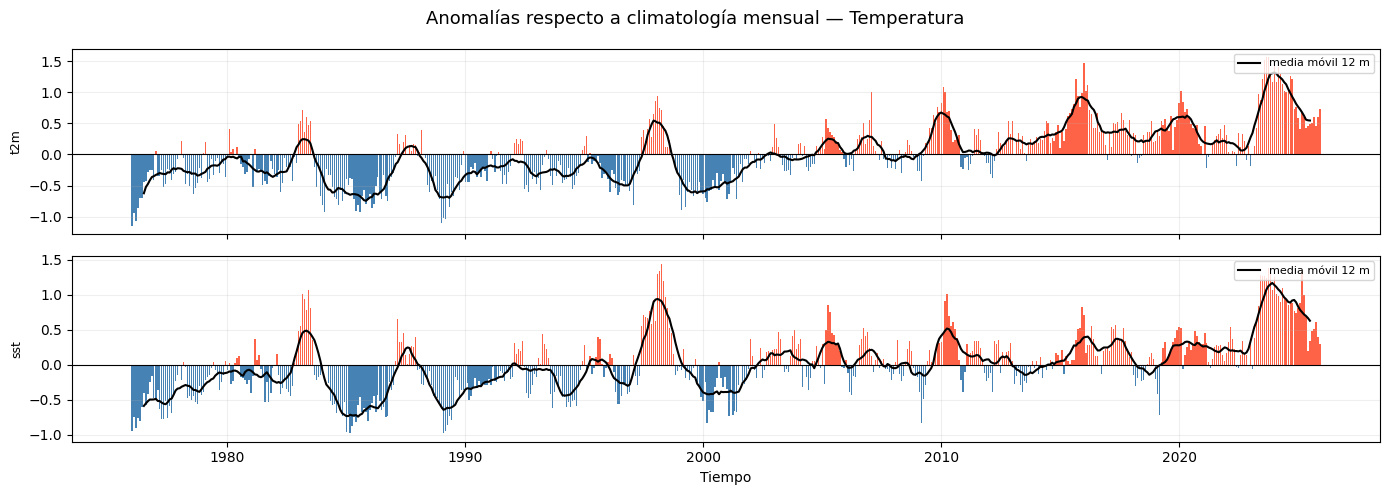

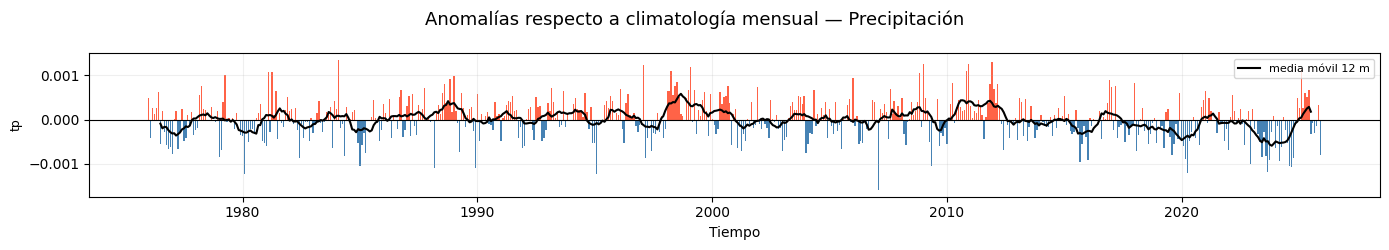

In [28]:
for nombre, vars_g in grupos.items():
    plot_anomalias(df_anom, vars_g, nombre)

- Tendencia de Temperaturas (t2m y sst): 
    Las gráficas de temperatura muestran una correlación casi perfecta entre la atmósfera y el océano, revelando un cambio estructural en el clima:

    * **Transición de Fase:** Se observa un cambio drástico de un predominio de anomalías negativas (barras azules) en las décadas de los 70 y 80, hacia un dominio absoluto de anomalías positivas (barras rojas) a partir del año 2000.
    * **Aceleración Reciente:** La **media móvil de 12 meses** (línea negra) muestra que el periodo 2023-2024 es el más cálido del registro, superando los $1.0^{\circ}C$ de anomalía.
    * **Eventos Cíclicos:** Los picos pronunciados coinciden con años de fuerte influencia de **El Niño** (1998, 2016, 2024).

- Comportamiento de la Precipitación (tp): 
    A diferencia de la temperatura, la precipitación presenta una señal mucho más volátil ("ruidosa"):

    * **Variabilidad Extrema:** No hay una tendencia lineal tan marcada, pero sí una mayor amplitud en las oscilaciones recientes.
    * **Relación Hídrica:** Los periodos de mayor temperatura suelen coincidir con picos de precipitación positiva, sugiriendo una intensificación del ciclo hidrológico en años cálidos.

### **Ciclo estacional**

In [29]:
meses_nombres = ["Ene","Feb","Mar","Abr","May","Jun",
                 "Jul","Ago","Sep","Oct","Nov","Dic"]

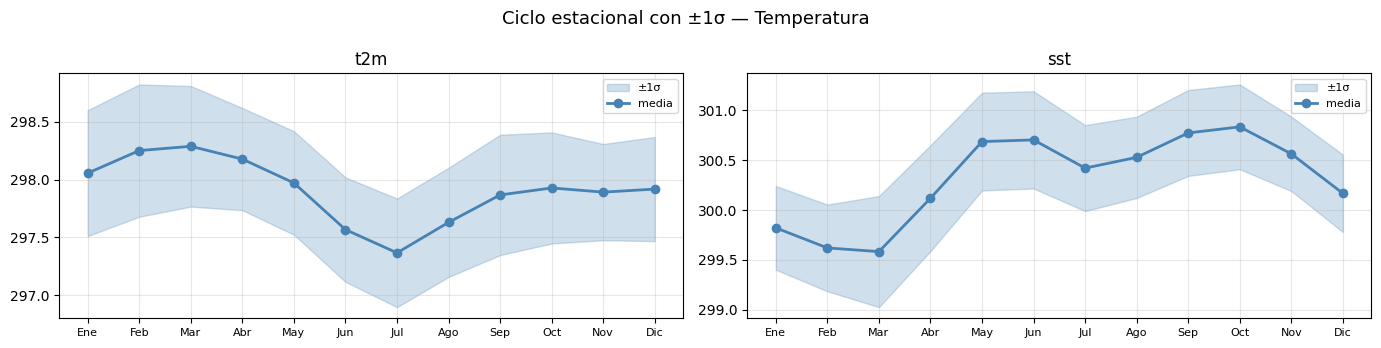

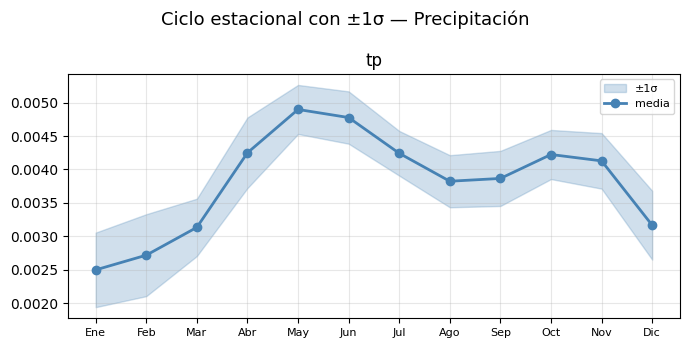

In [30]:
for nombre, vars_g in grupos.items():
    plot_ciclo_estacional(df_ts, vars_g, nombre,meses_nombres)

- Temperatura del Aire (t2m)
    * **Comportamiento Bimodal:** Presenta dos picos de calentamiento, siendo **marzo** el mes más caluroso ($~298.3 K$). 
    * **Mínimo Térmico:** Se observa un enfriamiento marcado que llega a su punto más bajo en **julio**.
    * **Variabilidad:** El sombreado ($\pm1\sigma$) es constante, lo que sugiere que la temperatura varía de forma similar año tras año.

- Temperatura superficial del mar (sst)
    * **Inercia y Desfase:** El mar alcanza su temperatura máxima en **mayo-junio** (posterior al pico del aire), superando los $300 K$.
    * **Evento de Enfriamiento:** Existe una caída notable en **julio**, posiblemente asociada a fenómenos de surgencia o cambios en corrientes superficiales.
    * **Influencia:** Los valores altos de SST coinciden con el inicio de la temporada de lluvias, actuando como fuente de energía y humedad.

- Precipitación Total (tp)
    * **Temporada de Lluvias:** El ciclo es claramente estacional. Las lluvias aumentan drásticamente en abril hasta alcanzar su **máximo en mayo**.
    * **La Canícula (Veranillo):** Se observa una disminución relativa de las lluvias en **agosto**, un fenómeno típico de regiones tropicales.
    * **Temporada Seca:** Los niveles más bajos de precipitación ocurren entre **enero y marzo**, coincidiendo con la fase de mayor radiación solar antes del pico térmico.

Realizamos a sus vez las pruebas estadisticas relacionadas a series de tiempo como Mann-Kendall y el test de estacionareidad ADF, asi como el analisis espectral para determinar los ciclos anuales e interanuales 

### **Prueba de Mann-Kendall y ciclos temporales**

Realizamos el metodo de Mann-Kendall

In [31]:
print(f"{'Variable':<10} {'Trend':<12} {'p-value':<12} {'Sen slope (u/mes)':<20} {'Sen slope (u/dec)'}")
for var in df_ts.columns:
    if var == 'month':
        continue
    result = mk_test(df_ts[var].dropna().values)
    slope_dec = result.slope * 12 * 10   # por década
    print(f"{var:<10} {result.trend:<12} {result.p:<12.4f} {result.slope:<20.6f} {slope_dec:.4f}")

Variable   Trend        p-value      Sen slope (u/mes)    Sen slope (u/dec)
t2m        increasing   0.0000       0.001740             0.2087
sst        increasing   0.0000       0.001416             0.1699
msl        increasing   0.0001       0.083015             9.9618
u10        increasing   0.0386       0.000238             0.0286
v10        no trend     0.9888       -0.000002            -0.0003
tp         no trend     0.2382       -0.000000            -0.0000
ssr        increasing   0.0126       336.483981           40378.0778
ssrd       increasing   0.0136       374.634515           44956.1418
strd       increasing   0.0000       283.000150           33960.0180
slhf       decreasing   0.0000       -415.429658          -49851.5589
e          decreasing   0.0000       -0.000000            -0.0000


Se aplicó el test no paramétrico de **Mann–Kendall** para evaluar la presencia de tendencias monótonas en las series temporales de las variables climáticas analizadas, junto con la estimación de la **pendiente de Sen** para cuantificar la magnitud del cambio. Este enfoque es robusto frente a valores extremos y no requiere el supuesto de normalidad.
- Temperatura:
    Los resultados muestran una **tendencia creciente estadísticamente significativa** en la temperatura del aire (**t2m**) y en la temperatura superficial del mar (**sst**), con incrementos aproximados de 0.21 y 0.17 unidades por década, respectivamente. Estas señales indican un **calentamiento sostenido del sistema atmósfera–océano** en la región de estudio.
- Presion y Viento: 
    La **presión a nivel del mar (msl)** también presenta una tendencia creciente significativa, lo que sugiere posibles cambios en los patrones de circulación atmosférica regional. De forma similar, la componente zonal del viento (**u10**) muestra una tendencia positiva débil pero estadísticamente significativa, mientras que la componente meridional (**v10**) no evidencia una tendencia detectable. No obstante, el análisis espacial revela que estas señales no son homogéneas, por lo que los resultados deben interpretarse como cambios integrados a escala regional.
- Radiación: 
    Las **variables radiativas (ssr, ssrd y strd)** exhiben tendencias crecientes significativas en las series temporales promedio. Sin embargo, la ausencia de patrones espaciales coherentes sugiere que estas tendencias reflejan cambios energéticos promedio, potencialmente asociados a variaciones en nubosidad o condiciones radiativas, más que una señal climática regional uniforme.
- flujo y evaporación: 
    Por el contrario, el **flujo de calor latente (slhf)** y la **evaporación (e)** presentan tendencias decrecientes significativas, indicando modificaciones en el intercambio de energía y humedad entre la superficie y la atmósfera. Estas disminuciones pueden estar relacionadas con cambios en la disponibilidad de humedad o en las condiciones termodinámicas superficiales.
- Precipitación: 
    La **precipitación total (tp)** no muestra una tendencia monótona estadísticamente significativa en la serie temporal regional, lo que indica estabilidad en los acumulados medios a largo plazo. Esto no descarta posibles cambios en la variabilidad intra-anual o en la frecuencia de eventos extremos, aspectos que requieren análisis específicos adicionales.

realizamos el analisis de los ciclos anuales e iteranuales 

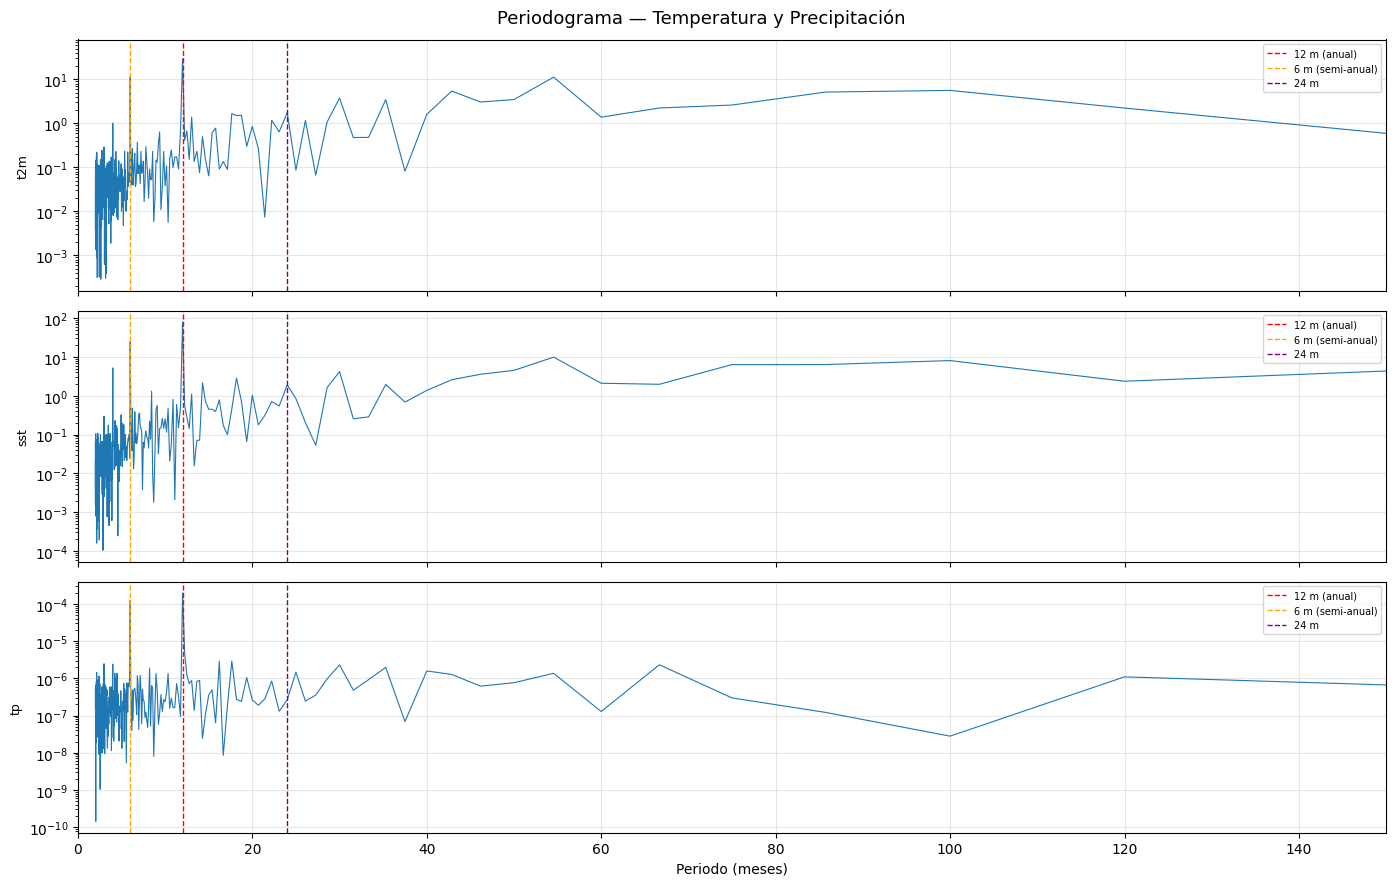

In [32]:
vars_tp_temp = ["t2m", "sst", "tp"]  
vars_tp_temp = [v for v in vars_tp_temp if v in df_ts.columns]
fig, axes = plt.subplots(len(vars_tp_temp), 1,
                         figsize=(14, 3 * len(vars_tp_temp)),
                         sharex=True)
if len(vars_tp_temp) == 1:
    axes = [axes]

for ax, var in zip(axes, vars_tp_temp):
    serie = df_ts[var].dropna().values
    freqs, power = periodogram(serie, fs=1)  
    mask = freqs > 0
    periodos = 1 / freqs[mask]

    ax.semilogy(periodos, power[mask], linewidth=0.8)
    ax.axvline(12, color='red', linestyle='--', linewidth=1, label='12 m (anual)')
    ax.axvline(6,  color='orange', linestyle='--', linewidth=1, label='6 m (semi-anual)')
    ax.axvline(24, color='purple', linestyle='--', linewidth=1, label='24 m')
    ax.set_xlim(0, 150)
    ax.set_ylabel(var, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Periodo (meses)")
fig.suptitle("Periodograma — Temperatura y Precipitación", fontsize=13)
plt.tight_layout()
plt.show()

El análisis espectral mediante periodogramas permite identificar las escalas temporales dominantes en la variabilidad de las series climáticas. En este caso, se evaluaron la temperatura del aire (t2m), la temperatura superficial del mar (sst) y la precipitación total (tp).
- Temperatura: 

    Para **t2m**, el periodograma muestra un **pico dominante alrededor de los 12 meses**, lo que evidencia un ciclo anual claramente definido. También se observa una señal secundaria en torno a los **6 meses**, asociada a un componente semi-anual, aunque de menor intensidad. La potencia disminuye hacia periodos más largos, indicando que la estacionalidad anual domina la variabilidad temporal de la temperatura del aire.

    La **sst** presenta un comportamiento similar, con un **máximo espectral en la escala anual (12 meses)**. Sin embargo, a diferencia de t2m, la potencia relativa en escalas mayores a un año es más persistente, lo que sugiere una **mayor memoria térmica del océano** y una respuesta más lenta a los forzamientos atmosféricos.
    
- Precipitacion:

    En contraste, la **precipitación (tp)** no muestra un pico anual claramente dominante. La potencia espectral se encuentra más dispersa entre diferentes periodos, reflejando una **alta variabilidad intra-anual** y un carácter más irregular y episódico. Esto indica que la precipitación no está controlada principalmente por un ciclo periódico simple, sino por procesos dinámicos más complejos.

En conjunto, el periodograma confirma una **estacionalidad fuerte y bien definida en las variables de temperatura**, mientras que la **precipitación presenta un comportamiento espectral más ruidoso y menos periódico**. Estos resultados son consistentes con los análisis de tendencia previos y resaltan la necesidad de enfoques diferenciados para el estudio de la variabilidad y el modelado de estas variables.

Variable   ADF stat     p-value    Estacionaria?
--------------------------------------------------
t2m        -3.4224      0.0102     SÍ
sst        -4.5233      0.0002     SÍ
tp         -5.7735      0.0000     SÍ


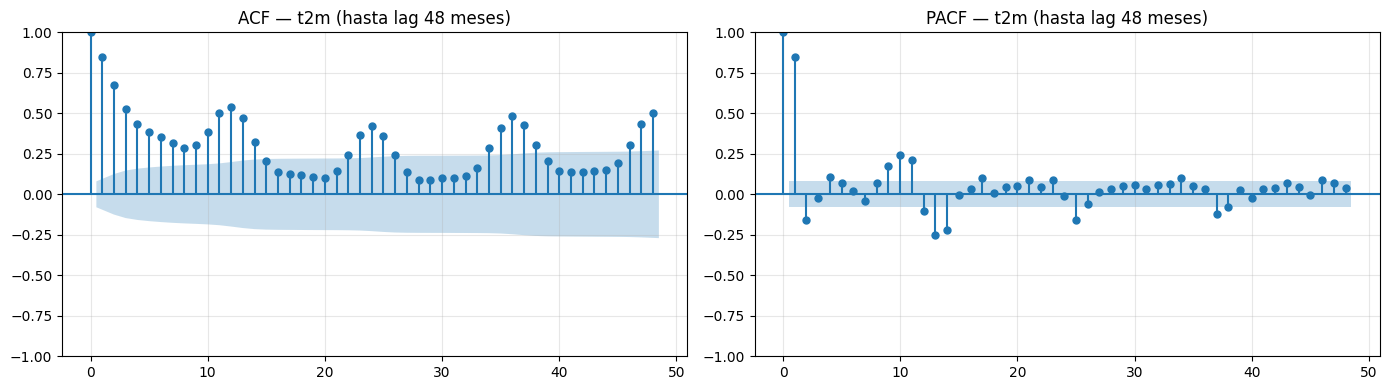

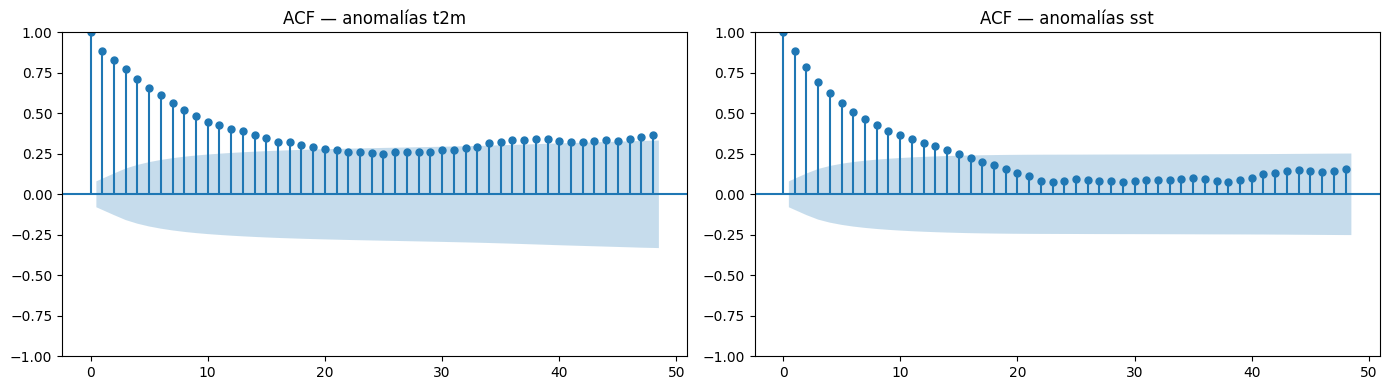

In [33]:
# ── ADF + ACF + PACF ─────────────────────────────────────────────────────────
target_vars = [v for v in vars_tp_temp if v in df_ts.columns]

print(f"{'Variable':<10} {'ADF stat':<12} {'p-value':<10} {'Estacionaria?'}")
print("-" * 50)
for var in target_vars:
    serie = df_ts[var].dropna()
    adf_result = adfuller(serie, autolag='AIC')
    estacionaria = "SÍ" if adf_result[1] < 0.05 else "NO"
    print(f"{var:<10} {adf_result[0]:<12.4f} {adf_result[1]:<10.4f} {estacionaria}")

# ── Gráfica ACF + PACF para t2m (variable objetivo) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_ts['t2m'].dropna(),  lags=48, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — t2m (hasta lag 48 meses)")
axes[0].grid(alpha=0.3)

plot_pacf(df_ts['t2m'].dropna(), lags=48, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title("PACF — t2m (hasta lag 48 meses)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── ACF de anomalías para ver persistencia ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_anom['t2m'].dropna(),  lags=48, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — anomalías t2m")

plot_acf(df_anom['sst'].dropna(), lags=48, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF — anomalías sst")

plt.tight_layout()
plt.show()

## Dimension Espacial

se realiza un analisis espacial con el analisis de mapas climatologicos y la variabilidad espacial de estos mapas, para analizar de esta manera el patron espacial promedio considerando todo el rango de tiempo

Los datos corresponden a promedios mensuales por año. 
Por tanto, los análisis espaciales representan climatologías 
multianuales de promedios mensuales, y la variabilidad temporal 
refleja cambios interanuales y estacionales combinados, no 
variabilidad de alta frecuencia (diaria u horaria).

### **Mapas climatologicos por variable**

Realizamos mapas climatologicos mostrandolos de manera organizada para mayor facilidad de analisis

In [34]:
def detectar_dim(ds, claves):
    for d in ds.dims:
        if any(k in d.lower() for k in claves):
            return d
    return None

lat_dim  = detectar_dim(ds, ["lat"])
lon_dim  = detectar_dim(ds, ["lon"])
time_dim = detectar_dim(ds, ["time"])
step_dim = detectar_dim(ds, ["step"])

print(f"lat={lat_dim}, lon={lon_dim}, time={time_dim}, step={step_dim}")

lat=latitude, lon=longitude, time=time, step=step


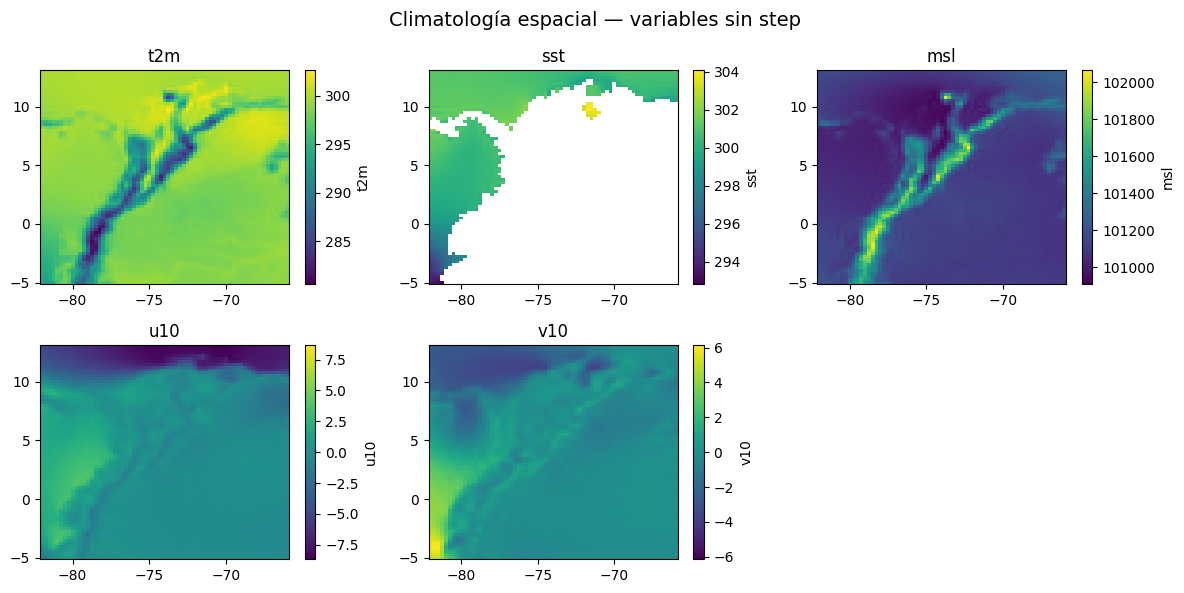

In [35]:
vars_no_step = ["t2m", "sst", "msl", "u10", "v10"]

ds_clim_no_step = ds[vars_no_step].mean(dim=time_dim, skipna=True)

ncols = 3
nrows = int(np.ceil(len(vars_no_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_no_step):
    da = ds_clim_no_step[var]
    da.plot(ax=ax, cmap="viridis", add_colorbar=True)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Ocultar ejes vacíos
for ax in axes[len(vars_no_step):]:
    ax.axis("off")

plt.suptitle("Climatología espacial — variables sin step", fontsize=14)
plt.tight_layout()
plt.show()

Las variables sin dimensión `step` representan estados instantáneos o promediables del sistema atmósfera–océano y permiten la construcción directa de mapas climatológicos mediante el promedio temporal del período de estudio.

- Temperatura a 2 m (`t2m`):
La climatología espacial de la temperatura a 2 m muestra un gradiente espacial coherente con la distribución regional de superficie continental y oceánica. Se observan valores más homogéneos sobre el océano y mayor variabilidad sobre zonas continentales, lo cual es físicamente consistente. La ausencia de discontinuidades o artefactos espaciales confirma la calidad del campo y su idoneidad como variable objetivo en etapas posteriores de modelado.

- Temperatura superficial del mar (`sst`):
El campo medio de la temperatura superficial del mar presenta una distribución suave y continua, con una clara delimitación entre regiones oceánicas y continentales. Este patrón confirma la correcta aplicación de la máscara tierra–mar en el dataset. Dado su carácter oceánico, esta variable no es directamente interpretable sobre tierra, lo cual debe considerarse en el preprocesamiento y selección de predictores.

- Presión a nivel del mar (`msl`):
La climatología de la presión a nivel del mar exhibe gradientes espaciales amplios y estructuras de gran escala, asociadas a patrones sinópticos persistentes. La baja variabilidad espacial relativa sugiere que esta variable actúa principalmente como un forzamiento de fondo, aportando contexto dinámico más que variabilidad local.

- Componentes del viento a 10 m (`u10`, `v10`):
Los mapas climatológicos de las componentes zonal y meridional del viento evidencian patrones direccionales bien definidos, coherentes con la circulación atmosférica regional del Caribe. La marcada anisotropía espacial sugiere que el viento no debe ser tratado como una variable escalar simple, sino preferiblemente mediante su magnitud y/o codificación direccional, con el fin de capturar adecuadamente su influencia en el sistema.


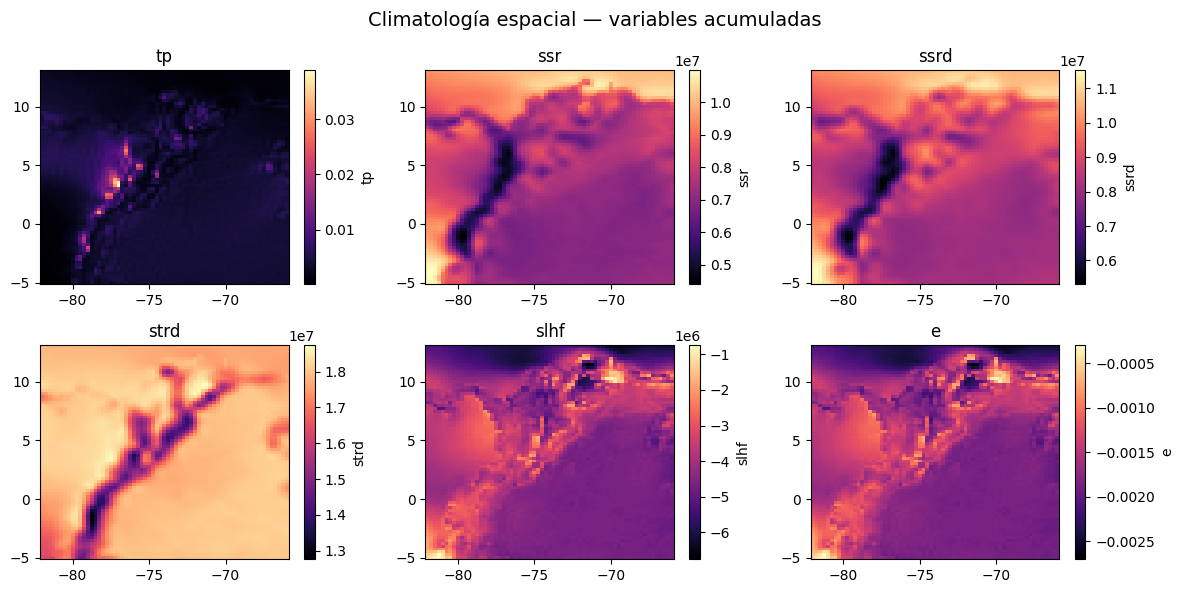

In [36]:
vars_step = ["tp", "ssr", "ssrd", "strd", "slhf", "e"]

ds_step_integrated = ds[vars_step].sum(dim=step_dim, skipna=True)
ds_clim_step = ds_step_integrated.mean(dim=time_dim, skipna=True)

ncols = 3
nrows = int(np.ceil(len(vars_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_step):
    da = ds_clim_step[var]
    da.plot(ax=ax, cmap="magma", add_colorbar=True)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(vars_step):]:
    ax.axis("off")

plt.suptitle("Climatología espacial — variables acumuladas", fontsize=14)
plt.tight_layout()
plt.show()

Las variables con dimensión `step` representan acumulaciones o integrales temporales asociadas a flujos energéticos e hídricos. Para garantizar consistencia física, estas variables fueron integradas sobre la dimensión `step` antes del cálculo de la climatología espacial.

- Precipitación total (`tp`):
La climatología de la precipitación total revela una alta heterogeneidad espacial, caracterizada por núcleos intensos localizados y extensas regiones de baja precipitación media. Este comportamiento refleja la naturaleza intermitente y altamente no lineal de la precipitación, dominada por eventos extremos. En términos de modelado, esta variable puede requerir transformaciones adicionales (por ejemplo, escalas logarítmicas o discretización) para reducir su asimetría.

- Radiación solar (`ssr`, `ssrd`):
Los campos climatológicos de la radiación solar superficial muestran patrones espaciales muy similares entre sí, con gradientes suaves y alta coherencia regional. Esta similitud sugiere una fuerte correlación entre ambas variables, indicando redundancia informativa. En consecuencia, resulta metodológicamente razonable considerar la exclusión de una de ellas en etapas posteriores de selección de variables.

- Radiación térmica descendente (`strd`):
La radiación térmica descendente presenta un patrón espacial distinto al de la radiación solar, con una distribución estrechamente relacionada con la temperatura atmosférica y superficial. Esta variable constituye un componente clave del balance energético y se perfila como un predictor relevante para variables térmicas como `t2m`.

- Flujo de calor latente (`slhf`): 
El flujo de calor latente muestra valores predominantemente negativos, coherentes con la convención física asociada a la transferencia de energía desde la superficie hacia la atmósfera. Su alta variabilidad espacial refleja diferencias regionales en los procesos de evaporación y convección, destacando su importancia en la dinámica local del sistema.

- Evaporación (`e`): 
La climatología de la evaporación presenta patrones espaciales muy similares a los observados en el flujo de calor latente, diferenciándose principalmente por la escala de magnitud. Esta fuerte similitud indica una elevada correlación entre ambas variables, sugiriendo redundancia. Por tanto, no resulta necesario incluir simultáneamente ambas variables en el conjunto de predictores.

### **Variabilidad espacial**

se verficia a su vez la variabilidad espacial para verificar donde varian mas las variables a nivel espacial y ver cuales son las zonas mas estables climaticamente

### Variables sin step (instantáneas)

In [37]:
ds_std_no_step = ds[vars_no_step].std(dim=time_dim, skipna=True)

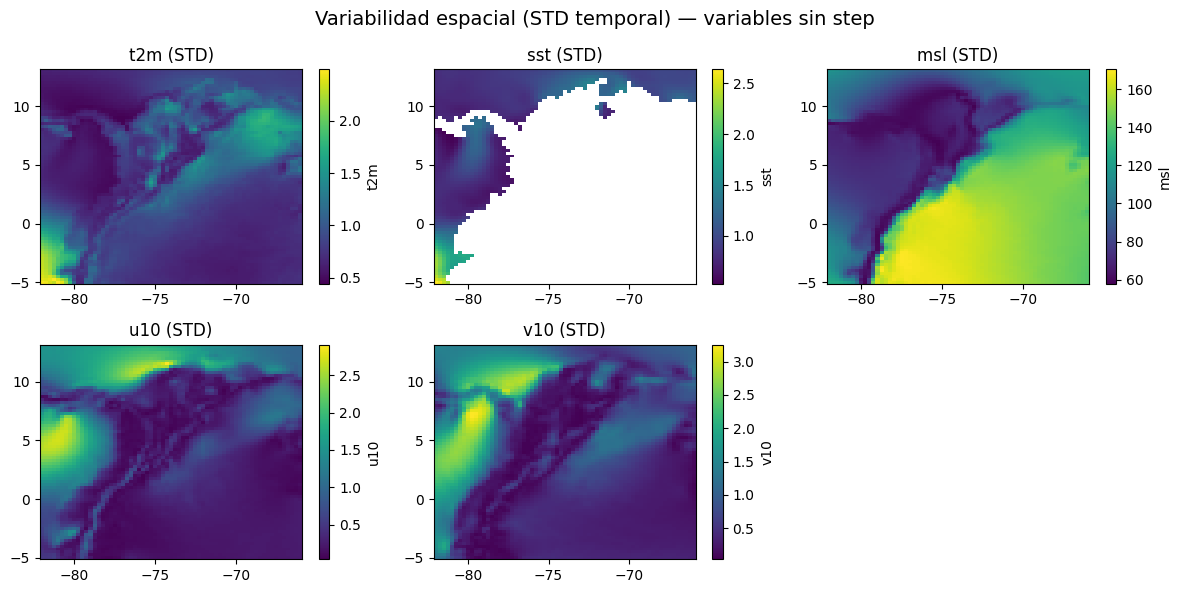

In [38]:
ncols = 3
nrows = int(np.ceil(len(vars_no_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_no_step):
    da = ds_std_no_step[var]
    da.plot(ax=ax, cmap="viridis", add_colorbar=True)
    ax.set_title(f"{var} (STD)")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(vars_no_step):]:
    ax.axis("off")

plt.suptitle("Variabilidad espacial (STD temporal) — variables sin step", fontsize=14)
plt.tight_layout()
plt.show()

**`t2m` — Temperatura a 2 metros**  
La mayor variabilidad (STD ~2°C) se concentra en la zona andina y continental, lo cual es esperable: la orografía introduce fuertes gradientes térmicos. El océano exhibe STD baja, reflejando un comportamiento térmico más estable temporalmente.

**`sst` — Temperatura superficial del mar**  
Alta variabilidad en la costa pacífica colombiana y el norte del Caribe. La zona enmascarada en tierra es correcta. La variabilidad en el Pacífico Este tropical puede estar capturando señal de **ENSO** (variabilidad interanual).

**`msl` — Presión a nivel del mar**  
Patrón muy marcado: alta STD sobre tierra (especialmente Andes, >140 Pa) y baja en el Caribe abierto. Esto puede reflejar efectos orográficos y térmicos continentales, pero también puede constituir una **señal espuria** derivada de la reducción de presión al nivel del mar sobre topografía compleja. *Se recomienda verificar este comportamiento antes de usar `msl` como predictor en zonas de alta elevación.*

**`u10` / `v10` — Viento a 10 metros**  
Ambas componentes muestran alta variabilidad en la costa Pacífica y la franja ITCZ. La baja STD en el Caribe central confirma un régimen de **vientos alisios estable y persistente**. Notably, `v10` (componente meridional) presenta mayor variabilidad que `u10`, consistente con el desplazamiento N-S de la ITCZ a lo largo del año.

### Variables acumuladas

In [39]:
# Integrar acumulados
ds_step_integrated = ds[vars_step].sum(dim=step_dim, skipna=True)

# STD temporal
ds_std_step = ds_step_integrated.std(dim=time_dim, skipna=True)

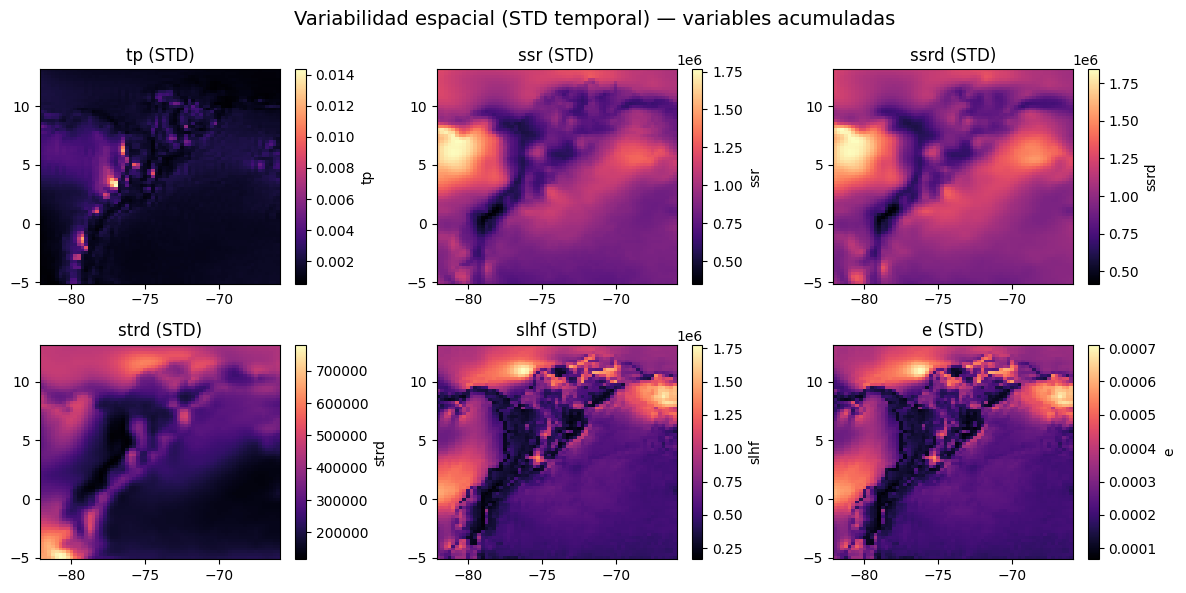

In [40]:
ncols = 3
nrows = int(np.ceil(len(vars_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_step):
    da = ds_std_step[var]
    da.plot(ax=ax, cmap="magma", add_colorbar=True)
    ax.set_title(f"{var} (STD)")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(vars_step):]:
    ax.axis("off")

plt.suptitle("Variabilidad espacial (STD temporal) — variables acumuladas", fontsize=14)
plt.tight_layout()
plt.show()

**`tp` — Precipitación total**  
STD muy alta y **espacialmente puntual sobre los Andes**, con un patrón pixelado característico de la convección orográfica intensa. La precipitación oceánica es más homogénea. Esta variable requiere tratamiento especial dada su naturaleza intermitente y distribución sesgada.

**`ssr` / `ssrd` — Radiación solar neta y descendente**  
Patrón suave y estructurado con máxima variabilidad en la franja tropical continental (~5°N). La gradiente N-S clara refleja el movimiento estacional de la **ITCZ** modulando la nubosidad. Ambas variables presentan patrones casi idénticos, indicando alta **colinealidad** entre ellas.

**`strd` — Radiación de onda larga descendente**  
Variabilidad moderada, mayor sobre tierra. Relacionada con variaciones de temperatura atmosférica y contenido de humedad en la columna.

**`slhf` — Flujo de calor latente superficial**  
Alta STD en zonas costeras y oceánicas tropicales, especialmente en el Pacífico. Conecta directamente con la variabilidad de SST y viento. Los mínimos sobre tierra sugieren que el flujo latente continental está más limitado por la disponibilidad de humedad del suelo.

**`e` — Evaporación**  
Patrón muy similar a `slhf`, lo cual es físicamente consistente (variables acopladas). Alta STD en el Pacífico Este tropical refuerza la posible huella de variabilidad interanual (ENSO).


### **Mapa de tendencia espacial**

Dado que solo las variables térmicas (t2m y sst) presentan tendencias espacialmente coherentes y estadísticamente significativas en la región de estudio,ademas de ser las variables princiaples, el análisis posterior de tendencia espacial se centra exclusivamente en estas variables, evitando interpretaciones sobre campos dominados por ruido o alta variabilidad interna.

In [41]:
# Metadatos por variable: (etiqueta unidades, factor conversión, rango colorbar)
var_meta = {
    "t2m":  ("°C/década",      12 * 10,      (-0.5,  0.5)),
    "sst":  ("°C/década",      12 * 10,      (-0.5,  0.5)),
    "msl":  ("hPa/década",     12 * 10,      (-2.0,  2.0)),
    "u10":  ("m/s/década",     12 * 10,      (-0.3,  0.3)),
    "v10":  ("m/s/década",     12 * 10,      (-0.3,  0.3)),
    "tp":   ("mm/década",      12 * 10 * 1000, (-10,  10)),   # m → mm
    "ssr":  ("W·h/m²/década",  12 * 10,      (-5e6, 5e6)),
    "ssrd": ("W·h/m²/década",  12 * 10,      (-5e6, 5e6)),
    "strd": ("W·h/m²/década",  12 * 10,      (-5e6, 5e6)),
    "slhf": ("W·h/m²/década",  12 * 10,      (-5e6, 5e6)),
    "e":    ("mm/década",      12 * 10 * 1000, (-5,   5)),    # m → mm
}

In [42]:
# ── Variables térmicas ─────────────────────────────────────────────
vars_temp = ["t2m", "sst"]

var_meta_temp = {
    k: v for k, v in var_meta.items() if k in vars_temp
}

In [43]:
# ── Paso 1: calcular tendencia por celda para cada variable ───────────────────
lats = ds['t2m'].latitude.values
lons = ds['t2m'].longitude.values
nlat, nlon = len(lats), len(lons)

In [44]:
# Preparar dataset unificado sin dimensión step
ds_step_integrated = ds[vars_step].sum(dim="step", skipna=True)
ds_full = xr.merge([ds[vars_no_step], ds_step_integrated])

In [45]:
results = {}   # var → {"slopes": ..., "pvalues": ...}

for var in var_meta_temp:
    print(f"  Calculando Mann-Kendall: {var}...", end=" ")
    
    da = ds_full[var]
    slopes_v  = np.full((nlat, nlon), np.nan)
    pvalues_v = np.full((nlat, nlon), np.nan)
    factor, _ = var_meta[var][1], var_meta[var][2]   # desempacar

    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            serie = da.sel(latitude=lat, longitude=lon).values
            if not np.isnan(serie).any():
                res = mk_test(serie)
                slopes_v[i, j]  = res.slope * var_meta[var][1]
                pvalues_v[i, j] = res.p

    results[var] = {"slopes": slopes_v, "pvalues": pvalues_v}

print("\nCálculo completado.")

  Calculando Mann-Kendall: t2m...   Calculando Mann-Kendall: sst... 
Cálculo completado.


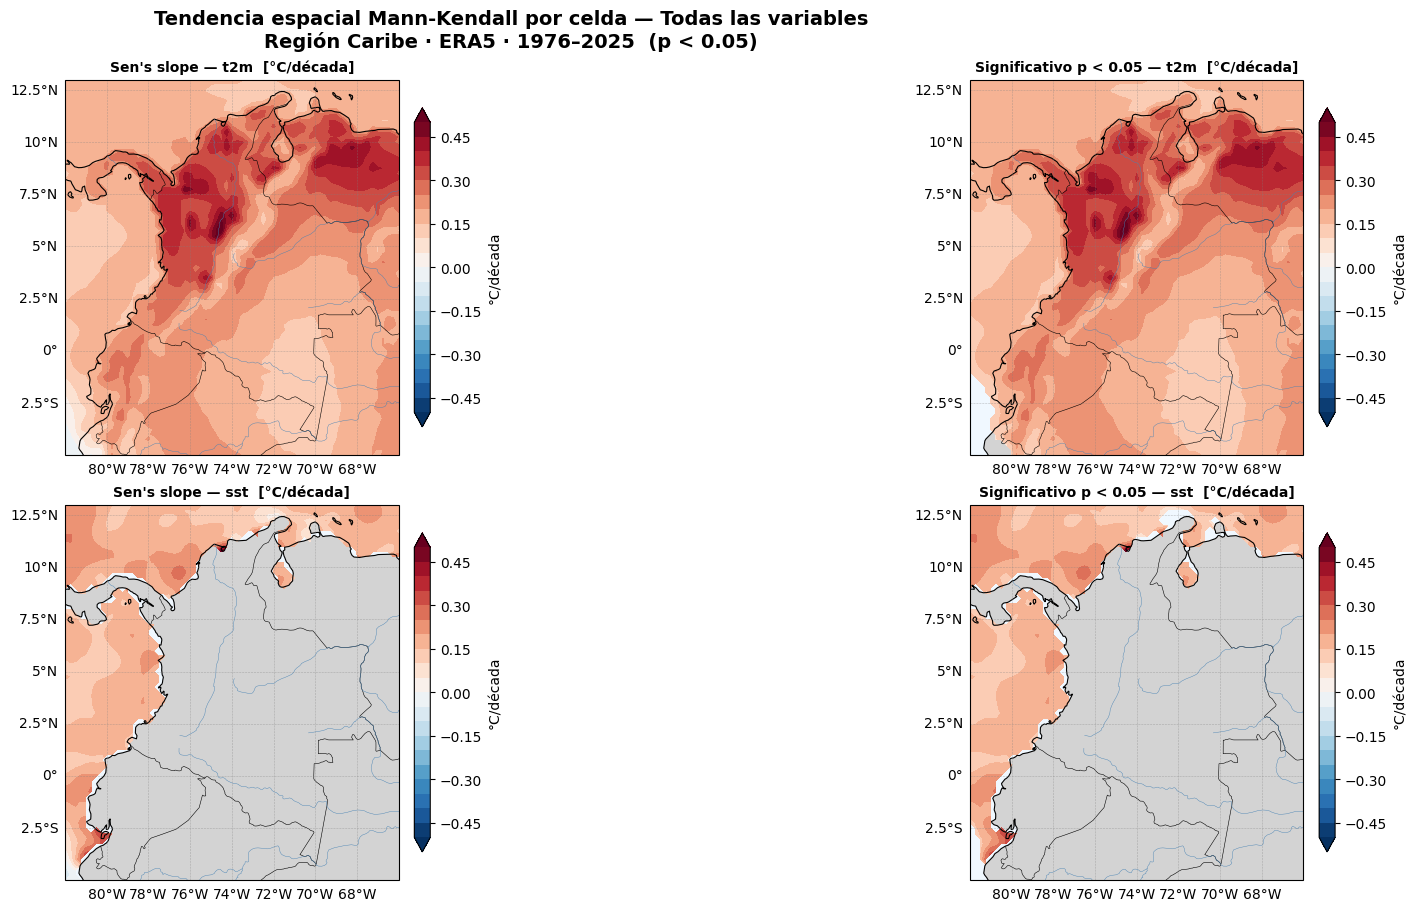

In [46]:
all_vars = list(var_meta_temp.keys())
n_vars   = len(all_vars)          
n_cols   = 2                      # slope | significativo
n_rows   = n_vars                 # una fila por variable

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 4.5 * n_rows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

cmap     = "RdBu_r"
p_thresh = 0.05

for row, var in enumerate(all_vars):
    unit, factor, (vmin, vmax) = var_meta[var]
    slopes_v  = results[var]["slopes"]
    pvalues_v = results[var]["pvalues"]
    sig_mask  = np.where(pvalues_v < p_thresh, slopes_v, np.nan)
    levels    = np.linspace(vmin, vmax, 21)

    for col, (data, titulo_col) in enumerate([
        (slopes_v, f"Sen's slope — {var}  [{unit}]"),
        (sig_mask,  f"Significativo p < {p_thresh} — {var}  [{unit}]"),
    ]):
        ax = axes[row, col]

        cf = ax.contourf(
            lons, lats, data,
            levels=levels,
            cmap=cmap,
            extend="both",
            transform=ccrs.PlateCarree()
        )
        ax.coastlines(resolution="50m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,     linewidth=0.4)
        ax.add_feature(cfeature.LAND,        facecolor="lightgray", zorder=0)
        ax.add_feature(cfeature.OCEAN,       facecolor="aliceblue", zorder=0)
        ax.add_feature(cfeature.RIVERS,      linewidth=0.3, edgecolor="steelblue")

        # Gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                          color="gray", alpha=0.5, linestyle="--")
        gl.top_labels   = False
        gl.right_labels = False

        ax.set_title(titulo_col, fontsize=10, fontweight="bold")
        plt.colorbar(cf, ax=ax, orientation="vertical",
                     shrink=0.85, pad=0.02, label=unit)

fig.suptitle(
    "Tendencia espacial Mann-Kendall por celda — Todas las variables\n"
    f"Región Caribe · ERA5 · 1976–2025  (p < {p_thresh})",
    fontsize=14, fontweight="bold",ha="center",x=0.5
)
plt.show()

Los mapas de tendencia espacial obtenidos mediante la prueba de **Mann–Kendall por celda**, junto con la **pendiente de Sen**, evidencian una señal térmica clara y robusta en la región Caribe durante el período 1976–2025.

- Temperatura del aire a 2 m (t2m)
    El campo de la pendiente de Sen muestra **tendencias positivas generalizadas** en prácticamente toda la región de estudio, con valores que alcanzan aproximadamente **0.4–0.5 °C por década** en amplias zonas del norte y centro del dominio.  
    El mapa de significancia (p < 0.05) revela que **la mayor parte de estas tendencias son estadísticamente significativas**, lo que indica que el aumento de la temperatura del aire no solo es persistente en el tiempo, sino también **espacialmente coherente**.  
    Las mayores magnitudes se concentran sobre el norte de Colombia y áreas adyacentes al Caribe, lo que sugiere un **calentamiento regional sostenido**, consistente con señales de cambio climático observadas a escala global y regional.

- Temperatura superficial del mar (sst)
    La **sst** presenta igualmente **tendencias positivas** en el dominio oceánico, con valores comparables a los de t2m, aunque con una **mayor heterogeneidad espacial**.  
    Las áreas con significancia estadística (p < 0.05) se concentran principalmente en sectores específicos del Caribe, indicando que el calentamiento oceánico es **robusto pero no completamente homogéneo** en toda la región.  
Aun así, la coincidencia entre tendencias positivas de **t2m y sst** sugiere un **acoplamiento térmico atmósfera–océano**, reforzando la evidencia de un calentamiento integrado del sistema climático regional.

### **PCA con EOF**

In [47]:
# Calcular anomalías mensuales en el campo 3D
t2m_anom = ds['t2m'].groupby('time.month') - ds['t2m'].groupby('time.month').mean('time')

# Reshape: (time, lat*lon)
ntime  = t2m_anom.shape[0]
data2d = t2m_anom.values.reshape(ntime, -1)

# Eliminar columnas con NaN (tierra en SST, etc.)
mask_valid = ~np.isnan(data2d).any(axis=0)
data_clean = data2d[:, mask_valid]

In [48]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)

pca = PCA(n_components=4)
pca.fit(data_scaled)
scores = pca.transform(data_scaled)
print("Varianza explicada por cada EOF:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  EOF{i+1}: {v*100:.1f}%  (acumulado: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%)")

Varianza explicada por cada EOF:
  EOF1: 64.8%  (acumulado: 64.8%)
  EOF2: 9.4%  (acumulado: 74.1%)
  EOF3: 4.8%  (acumulado: 79.0%)
  EOF4: 3.9%  (acumulado: 82.9%)


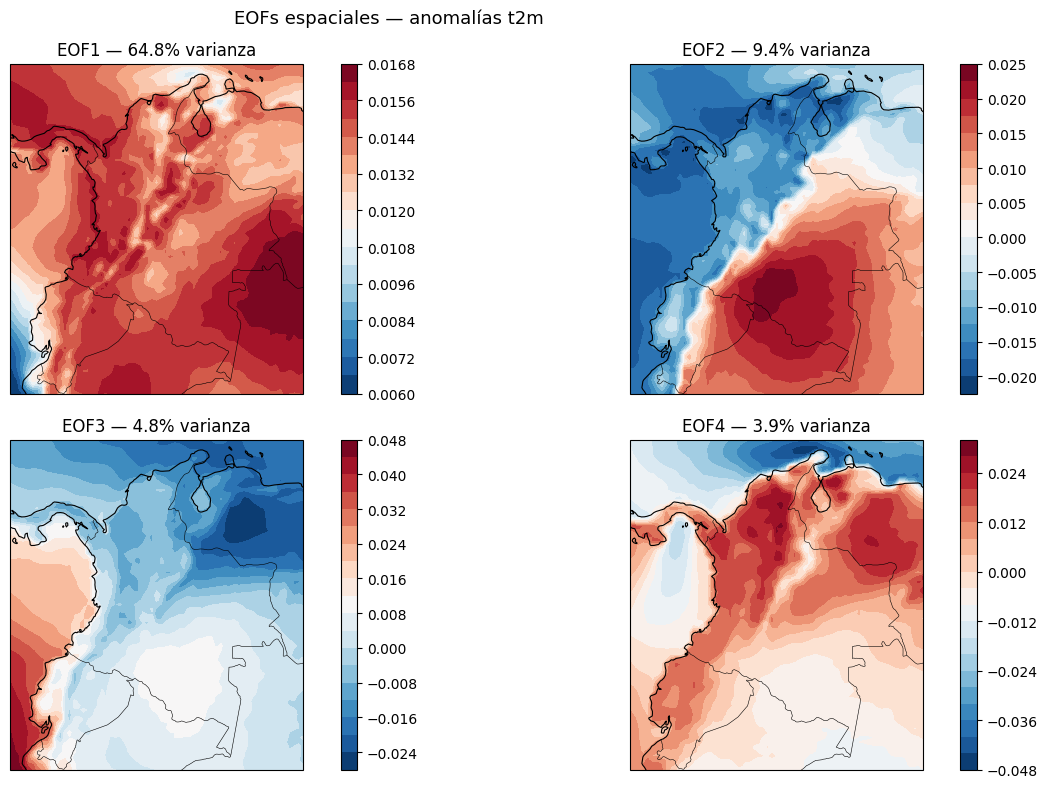

In [49]:
eof1_2d = np.full(data2d.shape[1], np.nan)
eof1_2d[mask_valid] = pca.components_[0]
eof1_map = eof1_2d.reshape(len(lats), len(lons))

fig, axes = plt.subplots(2, 2, figsize=(14, 8),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for k in range(4):
    eof_2d = np.full(data2d.shape[1], np.nan)
    eof_2d[mask_valid] = pca.components_[k]
    eof_map = eof_2d.reshape(len(lats), len(lons))
    
    im = axes[k].contourf(lons, lats, eof_map, levels=20,
                           cmap='RdBu_r', transform=ccrs.PlateCarree())
    axes[k].coastlines(resolution='50m', linewidth=0.8)
    axes[k].add_feature(cfeature.BORDERS, linewidth=0.4)
    plt.colorbar(im, ax=axes[k])
    var_exp = pca.explained_variance_ratio_[k] * 100
    axes[k].set_title(f"EOF{k+1} — {var_exp:.1f}% varianza")

fig.suptitle("EOFs espaciales — anomalías t2m", fontsize=13)
plt.tight_layout()
plt.show()

Los **EOFs (Empirical Orthogonal Functions)** permiten identificar los principales patrones espaciales de variabilidad de la temperatura a 2 m (t2m), junto con la fracción de varianza que explica cada uno.

- EOF1 — 64.8 % de la varianza
    - Es el **modo dominante** del sistema.
    - Presenta un patrón espacial **coherente**, con anomalías del mismo signo en la mayor parte del dominio.
    - Representa una **señal de gran escala**, asociada a forzamientos regionales o globales.
    - Puede interpretarse como el **componente principal del calentamiento/enfriamiento generalizado**.

- EOF2 — 9.4 % de la varianza
    - Muestra un **patrón dipolar**, con regiones que presentan anomalías de signo opuesto.
    - Indica **contrastes espaciales** (por ejemplo, costa–interior o norte–sur).
    - Está asociado a **redistribuciones regionales de temperatura**, posiblemente ligadas a patrones de circulación atmosférica.

- EOF3 — 4.8 % de la varianza
    - Presenta una estructura más **fragmentada y localizada**.
    - Representa **procesos secundarios**, como efectos orográficos o variabilidad regional.
    - Su interpretación física es **menos robusta** que la de los primeros modos.

- EOF4 — 3.9 % de la varianza
    - Corresponde a variabilidad de **menor escala espacial**.
    - Puede reflejar señales residuales estacionales o ruido estructurado.
    - Generalmente no se utiliza de forma aislada para conclusiones climáticas.

- Conclusión general
    - Los dos primeros EOFs explican aproximadamente **74 % de la varianza total**, lo que indica que la variabilidad de t2m está dominada por **pocos patrones espaciales principales**.
    - EOF1 describe la variabilidad térmica de **gran escala**, mientras que EOF2 introduce **contrastes regionales clave**.
    - EOF3 y EOF4 aportan detalle adicional, pero con menor peso interpretativo.

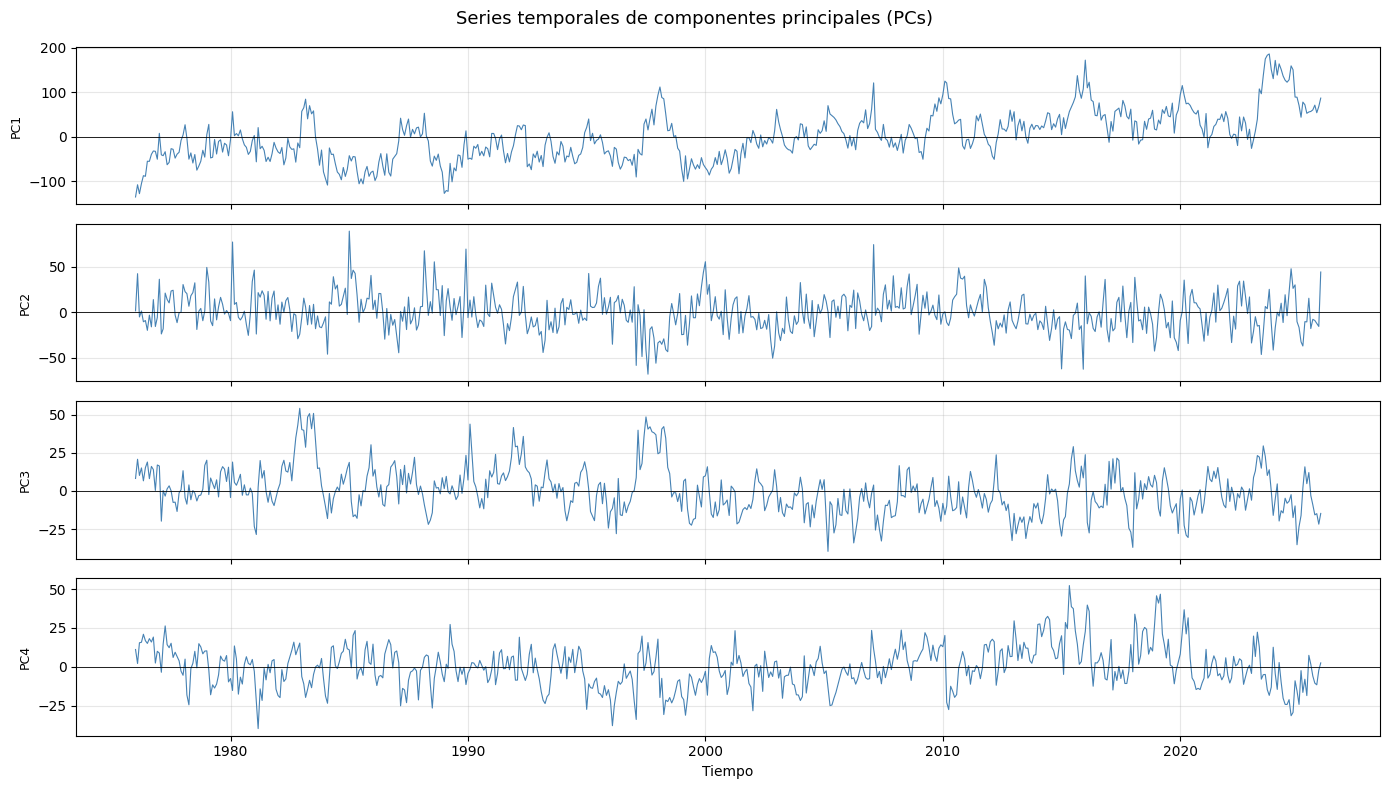

In [50]:
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(df_ts.index, scores[:, k], linewidth=0.8, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_ylabel(f"PC{k+1}", fontsize=9)
    ax.grid(alpha=0.3)
fig.suptitle("Series temporales de componentes principales (PCs)", fontsize=13)
axes[-1].set_xlabel("Tiempo")
plt.tight_layout()
plt.show()

Las **Componentes Principales (PCs)** describen la evolución temporal de los patrones espaciales identificados por los EOFs de las anomalías de t2m. Su análisis permite distinguir entre señales dominantes, variabilidad natural y modos secundarios.

- PC1 — Modo dominante
    - Presenta las **mayores amplitudes**, coherentes con el alto porcentaje de varianza explicado por el EOF1.
    - Muestra una **variabilidad de baja frecuencia**, con periodos prolongados de valores positivos y negativos.
    - Se observa una **tendencia positiva hacia los años más recientes**, lo que sugiere un fortalecimiento del patrón térmico de gran escala.
    - Indica la presencia de una **señal climática persistente**, asociada a calentamiento/enfriamiento generalizado.

- PC2 — Variabilidad interanual
    - Oscila alrededor de cero sin una tendencia clara.
    - Exhibe **cambios frecuentes de signo**, característicos de variabilidad interanual o interdecadal.
    - Está asociada a contrastes espaciales del EOF2, posiblemente vinculados a cambios en la circulación atmosférica.

- PC3 — Procesos secundarios
    - Amplitud moderada, menor que PC1 y PC2.
    - Presenta episodios puntuales de valores extremos, pero sin persistencia temporal marcada.
    - Representa **procesos regionales o locales**, con menor relevancia en la variabilidad total.

- PC4 — Variabilidad residual
    - Señal más ruidosa y de **menor coherencia temporal**.
    - Oscila rápidamente alrededor de cero.
    - Puede interpretarse como **variabilidad residual** o ruido estructurado.

## Dimension Multivariable

### Analisis univariado 

realizamos analisis univariado

In [51]:
df_ts.describe()

,t2m,sst,msl,u10,v10,tp,ssr,ssrd,strd,slhf,e,month
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02,6.000000e+02,6.000000e+02,6.000000e+02,600.000000,600.000000
mean,297.909607,300.318115,101147.546875,-0.742544,-0.278996,0.003810,7.693591e+06,8.685372e+06,1.761379e+07,-4.188290e+06,-0.001675,6.500000
std,0.548682,0.619823,90.305794,0.466263,0.612235,0.000865,5.408206e+05,6.150406e+05,1.758951e+05,2.857795e+05,0.000114,3.454933
min,296.549591,298.600647,100907.312500,-1.779237,-1.536195,0.001121,6.396513e+06,7.201546e+06,1.704058e+07,-4.849683e+06,-0.001939,1.000000
25%,297.547256,299.910156,101085.119141,-1.101839,-0.866543,0.003213,7.310394e+06,8.259488e+06,1.752116e+07,-4.409025e+06,-0.001763,3.750000
50%,297.869873,300.344269,101136.578125,-0.736899,-0.079616,0.003922,7.684014e+06,8.681974e+06,1.762778e+07,-4.176876e+06,-0.001670,6.500000
75%,298.237640,300.734055,101209.017578,-0.397913,0.249479,0.004435,8.070790e+06,9.113400e+06,1.773584e+07,-3.960422e+06,-0.001584,9.250000
max,299.697693,302.216858,101398.062500,0.582860,0.716381,0.005561,9.443648e+06,1.068164e+07,1.813644e+07,-3.562258e+06,-0.001424,12.000000


realizamos boxplots a nivel mensual de cada una de las variables 

In [52]:
def boxplot_mensual(df, var):
    plt.figure(figsize=(10,4))
    sns.boxplot(
        x="month",
        y=var,
        data=df,
        showfliers=False
    )
    plt.title(f"Distribución mensual de {var}")
    plt.xlabel("Mes")
    plt.ylabel(var)
    plt.grid(alpha=0.3)
    plt.show()

In [53]:
def boxplots_grupo(df, variables, titulo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        sns.boxplot(
            x="month",
            y=var,
            data=df,
            showfliers=False,
            ax=ax
        )
        ax.set_title(var)
        ax.grid(alpha=0.3)

    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

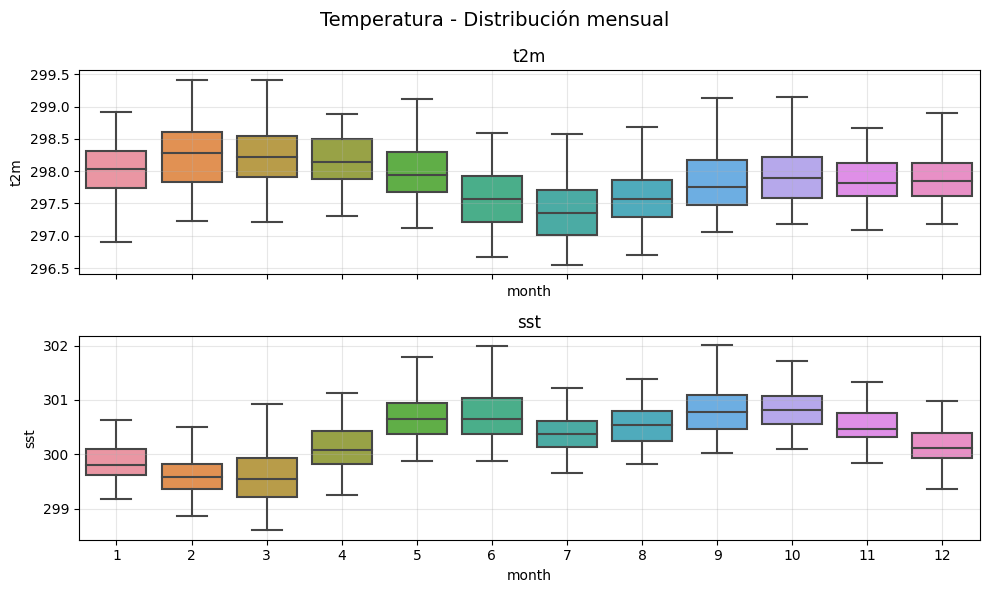

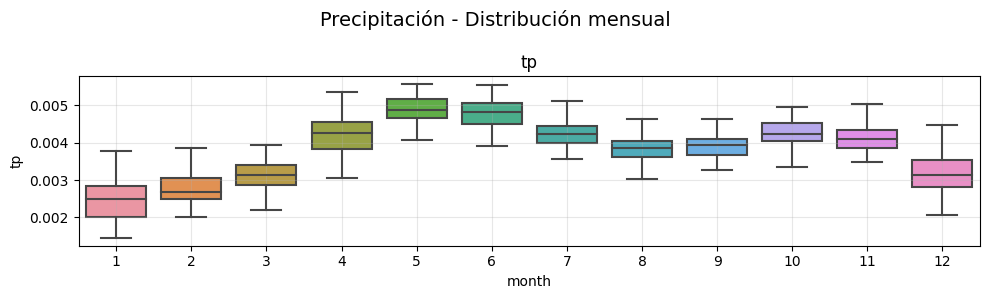

In [54]:
for grupo, vars_grupo in grupos.items():
    boxplots_grupo(
        df_ts,
        vars_grupo,
        f"{grupo} - Distribución mensual"
    )

### Analisis Normalidad 

In [55]:
vars_analizar = [v for v in df_ts.columns if v != "month"]

In [56]:
resultados_normalidad = []

for var in vars_analizar:
    serie = df_ts[var].dropna().values

    stat_sw,  p_sw  = stats.shapiro(serie)
    stat_da,  p_da  = stats.normaltest(serie)         # D'Agostino K²
    stat_ks,  p_ks  = stats.kstest(
        (serie - serie.mean()) / serie.std(), "norm"
    )

    skewness = stats.skew(serie)
    kurtosis = stats.kurtosis(serie)   # exceso de kurtosis (0 = normal)

    resultados_normalidad.append({
        "Variable"        : var,
        "Shapiro p-value" : round(p_sw, 4),
        "Normal (SW)"     : "normal" if p_sw  > 0.05 else "no_normal",
        "D'Agostino p"    : round(p_da, 4),
        "Normal (DA)"     : "normal" if p_da  > 0.05 else "no_normal",
        "KS p-value"      : round(p_ks, 4),
        "Normal (KS)"     : "normal" if p_ks  > 0.05 else "no_normal",
        "Skewness"        : round(skewness, 3),
        "Kurtosis (exc)"  : round(kurtosis, 3),
    })

df_normalidad = pd.DataFrame(resultados_normalidad).set_index("Variable")
print("=" * 70)
print("RESUMEN — Tests de normalidad (α = 0.05)")
print("=" * 70)
print(df_normalidad.to_string())

RESUMEN — Tests de normalidad (α = 0.05)
          Shapiro p-value Normal (SW)  D'Agostino p Normal (DA)  KS p-value Normal (KS)  Skewness  Kurtosis (exc)
Variable                                                                                                         
t2m                0.0002   no_normal        0.0003   no_normal      0.0913      normal     0.386           0.260
sst                0.6607      normal        0.8114      normal      0.9669      normal    -0.063          -0.010
msl                0.0000   no_normal        0.0003   no_normal      0.0517      normal     0.319          -0.412
u10                0.0000   no_normal        0.0000   no_normal      0.1079      normal     0.162          -0.659
v10                0.0000   no_normal        0.0000   no_normal      0.0000   no_normal    -0.415          -1.221
tp                 0.0000   no_normal        0.0001   no_normal      0.0146   no_normal    -0.419          -0.312
ssr                0.0168   no_normal        0.

Análisis de la normalidad de las variables

- La tabla de tests de normalidad (α = 0.05) evidencia que **la mayoría de las variables climáticas analizadas no siguen una distribución normal**, especialmente según los tests de **Shapiro–Wilk** y **D’Agostino–Pearson**, los cuales presentan mayor sensibilidad para detectar desviaciones de la normalidad en series temporales extensas.

- La variable **sst** es la única que cumple el supuesto de normalidad de forma consistente en los tres tests aplicados, además de presentar valores de asimetría y curtosis cercanos a cero, lo que indica una distribución aproximadamente normal. En contraste, variables como **tp** y **v10** rechazan la hipótesis de normalidad en todos los tests, reflejando distribuciones asimétricas y con desviaciones significativas respecto a la normal.

- El test de **Kolmogorov–Smirnov** tiende a aceptar la normalidad en más variables; sin embargo, este comportamiento es esperable debido a su menor potencia estadística, por lo que no se considera determinante frente a los resultados de Shapiro–Wilk y D’Agostino–Pearson.

- Los valores de **skewness** y **curtosis** indican que, aunque algunas variables presentan distribuciones visualmente cercanas a la normal, existen desviaciones estadísticas suficientes para rechazar dicho supuesto. Este comportamiento es característico de datasets climáticos, donde pequeñas desviaciones son detectadas en muestras grandes.

En conjunto, estos resultados **justifican el uso de métodos no paramétricos**, como el test de **Mann–Kendall** y la estimación de la **pendiente de Sen**, para el análisis de tendencias, al no cumplirse de manera generalizada el supuesto de normalidad en las series analizadas.

### Analisis outliers o eventos extremos

Para variables con distribuciones no normales y para las cuales la
frecuencia de extremos definida por percentiles resulta poco informativa,
se empleó un criterio robusto basado en la mediana y la desviación absoluta
mediana (MAD). Las anomalías robustas se calcularon como:

Z_rob = 0.6745 · (X − mediana) / MAD

considerándose eventos extremos aquellos con |Z_rob| > 2.5. Este enfoque
permite identificar regiones con mayor ocurrencia de eventos extremos sin
imponer una frecuencia uniforme en el dominio espacial.

In [61]:
# Variables cuasi-normales → Z-score clásico
vars_zscore = [
    "sst", "t2m", "msl", "u10", "ssr", "ssrd"
]

# Variables no normales → Z-score robusto
vars_robusto = [
    "tp", "v10", "strd", "slhf", "e"
]

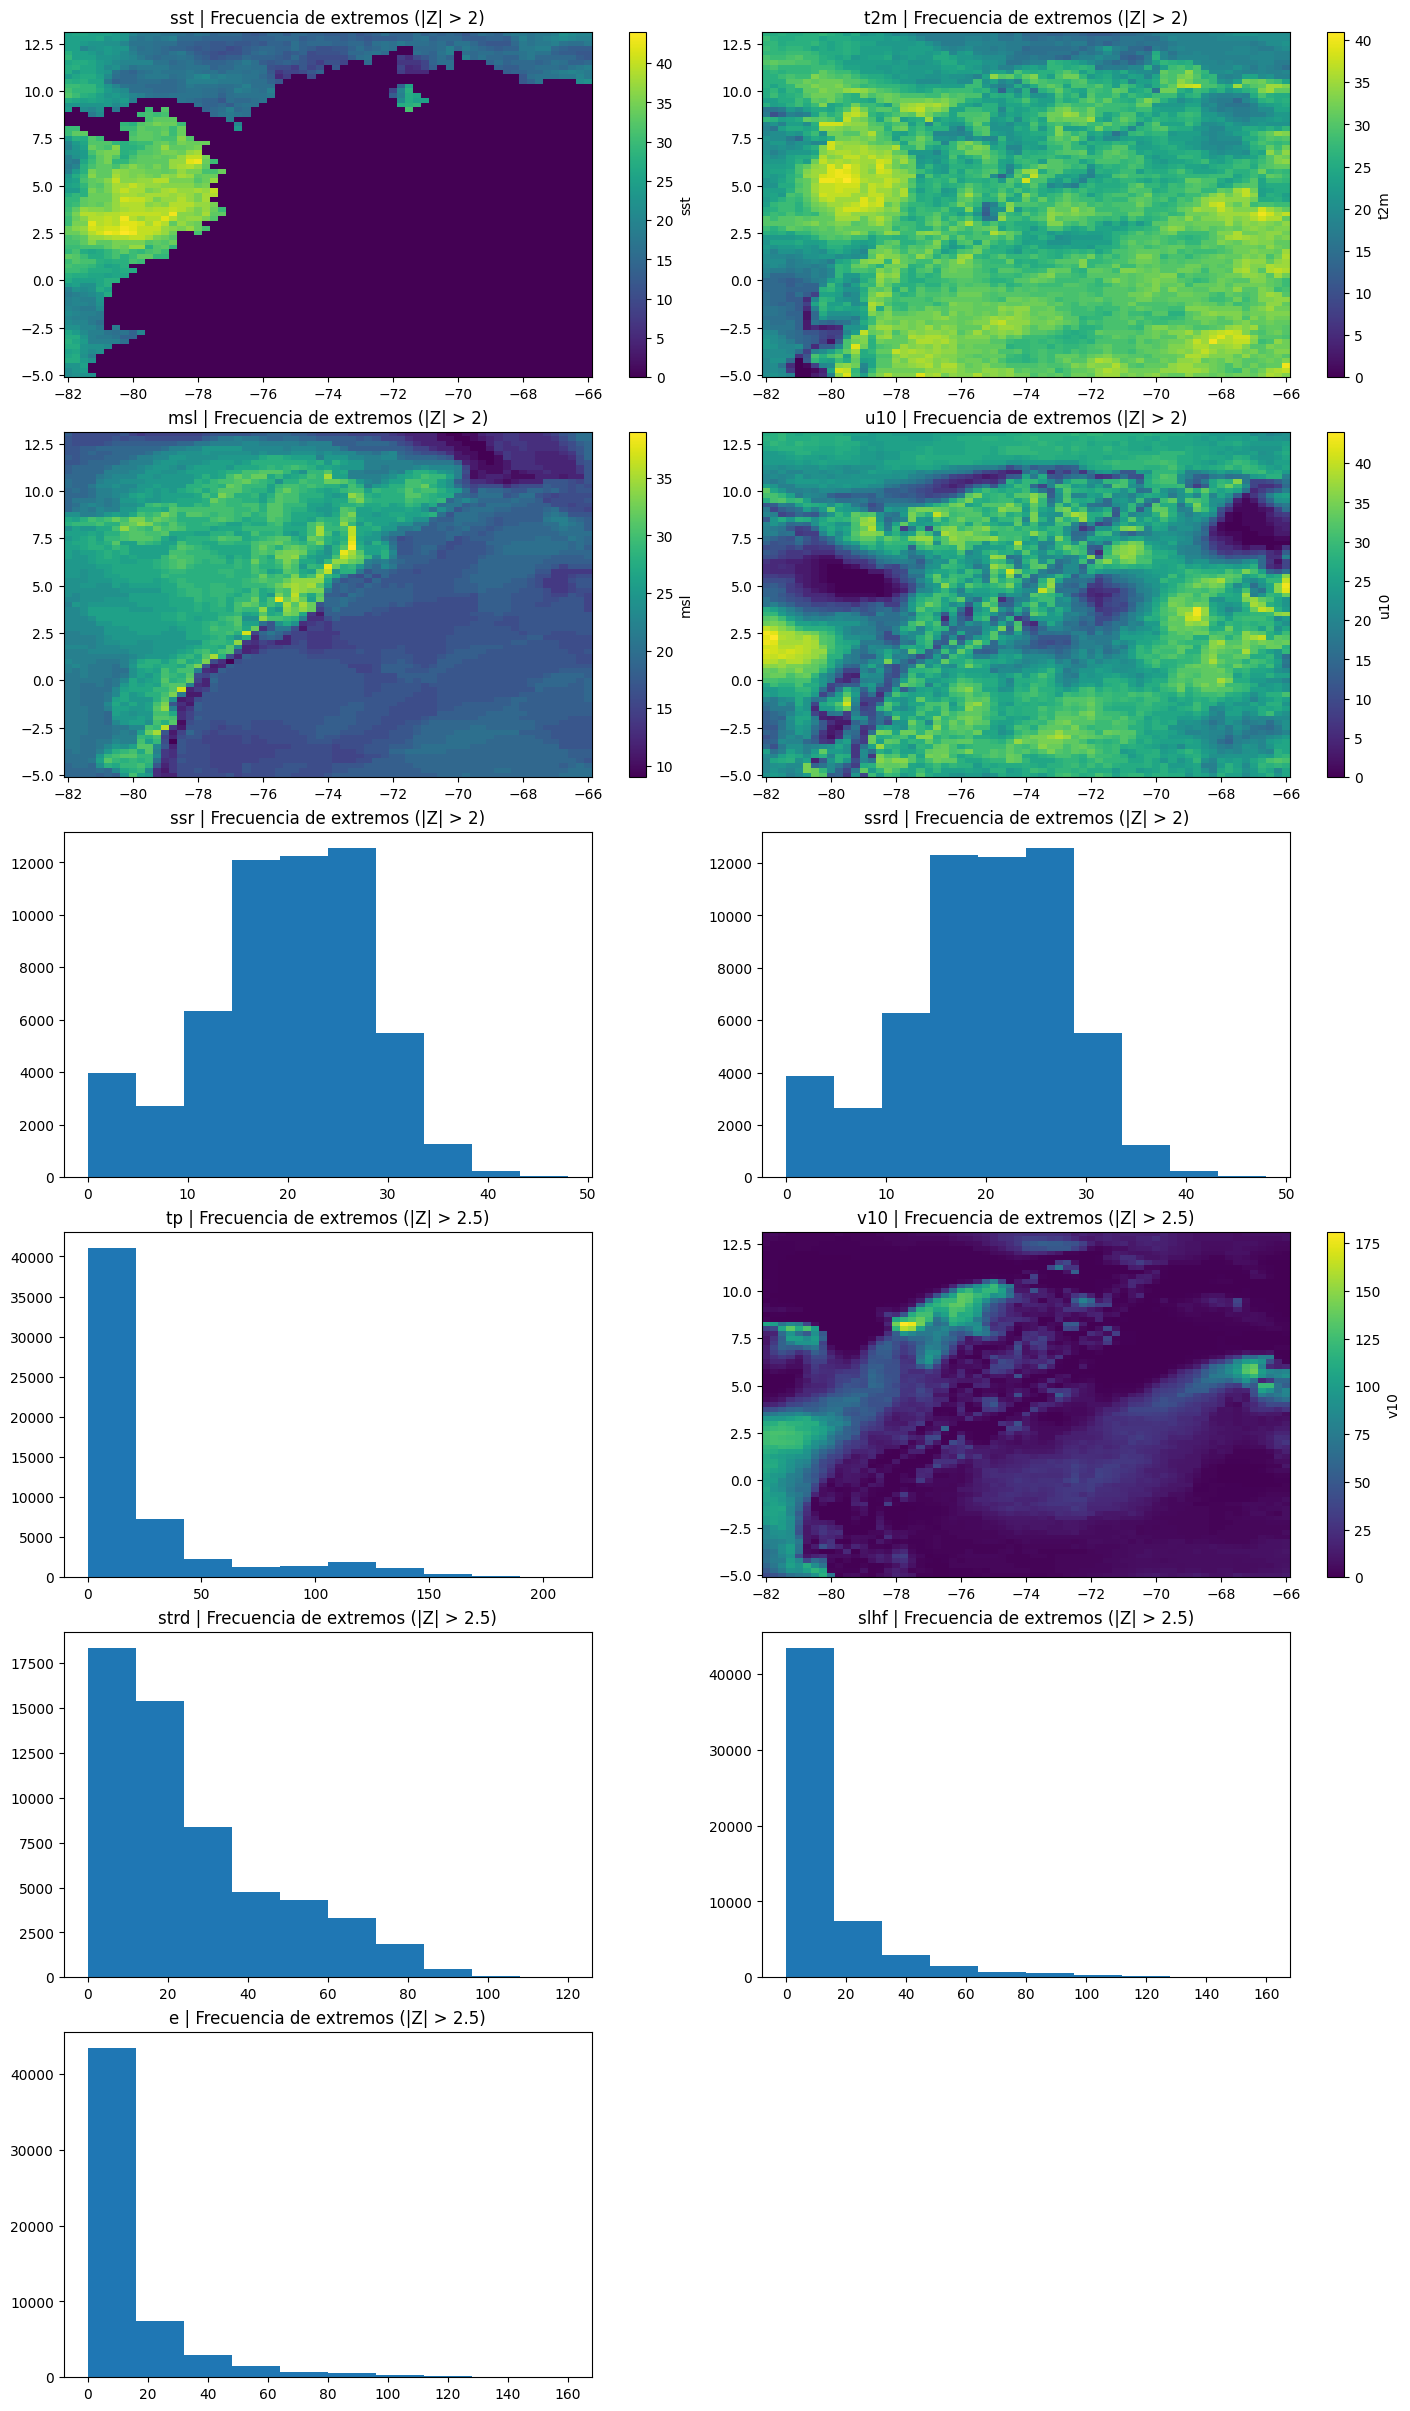

In [63]:
all_vars = vars_zscore + vars_robusto

resultados_extremos = {}

n_vars = len(all_vars)
ncols = 2
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(7 * ncols, 4 * nrows),
    constrained_layout=True
)

axes = axes.flatten()

for i, var in enumerate(all_vars):

    if var in vars_zscore:
        # ── Z-score clásico ─────────────────────────────
        z = (ds[var] - ds[var].mean("time")) / ds[var].std("time")
        extremos = z.where(np.abs(z) > 2)
        metodo = "|Z| > 2"

    elif var in vars_robusto:
        # ── Z_robusto ─────────────────────────────────
        median = ds[var].median("time")
        mad = np.abs(ds[var] - median).median("time")

        z_rob = 0.6745 * (ds[var] - median) / mad
        extremos = z_rob.where(np.abs(z_rob) > 2.5)
        metodo = "|Z| > 2.5"

    # Conteo temporal
    resultados_extremos[var] = extremos.count("time")

    # Plot
    resultados_extremos[var].plot(ax=axes[i])
    axes[i].set_title(f"{var} | Frecuencia de extremos ({metodo})")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

- Análisis de la frecuencia espacial de eventos extremos

La Figura presenta la distribución espacial de la **frecuencia de eventos extremos** para distintas variables atmosféricas y oceánicas, empleando un criterio adaptativo según la naturaleza estadística de cada variable. Para aquellas con comportamiento cuasi-gaussiano (SST, T2M, MSL, U10, SSR y SSRD) se utilizó el umbral de anomalías estandarizadas clásicas (|Z| > 2), mientras que para variables no normales o con distribuciones asimétricas (TP, V10, STRD, SLHF y E) se aplicó un criterio robusto basado en la mediana y la desviación absoluta mediana (|Z_rob| > 2.5).

- Variables termodinámicas de gran escala

    - **SST** muestra una clara diferenciación espacial, con una mayor frecuencia de eventos extremos concentrada en el sector occidental del dominio, asociada a regiones de mayor variabilidad térmica oceánica. Las áreas centrales presentan frecuencias significativamente menores, indicando un comportamiento más estable.
    - **T2M** exhibe un patrón más homogéneo, aunque con máximos relativos en regiones continentales y costeras, reflejando la influencia combinada de forzantes sinópticos y procesos locales.
    - **MSL** presenta una estructura espacial coherente, con bandas de mayor frecuencia alineadas con gradientes de presión persistentes, lo que sugiere una modulación por sistemas de circulación de gran escala.

- Variables dinámicas del viento

    - **U10** revela una marcada heterogeneidad espacial, con regiones bien definidas de alta frecuencia de extremos, asociadas a zonas de mayor actividad del viento zonal y a la influencia de circulaciones regionales.
    - **V10**, evaluada mediante un criterio robusto, muestra por primera vez una estructura espacial no homogénea. Se identifican núcleos de alta frecuencia en sectores específicos del dominio, lo que indica regiones con mayor variabilidad del viento meridional y episodios recurrentes de intensificación, evitando la artificial homogeneidad observada al usar percentiles.

- Flujos radiativos y de superficie

    - **SSR** y **SSRD** presentan distribuciones similares, con una mayor concentración de extremos en rangos intermedios de frecuencia y una menor ocurrencia de eventos extremos persistentes, reflejando la naturaleza relativamente estable de los flujos radiativos entrantes.
    - **STRD** muestra una distribución asimétrica de frecuencias, con predominio de valores bajos y una cola hacia frecuencias altas, lo que sugiere que los eventos extremos radiativos de onda larga descendente son relativamente poco frecuentes pero intensos en regiones específicas.

- Variables de intercambio superficie–atmósfera

    - **SLHF** y **E** presentan distribuciones altamente sesgadas, con la mayoría del dominio caracterizado por una baja frecuencia de extremos y un número reducido de regiones donde estos eventos ocurren de manera recurrente. Este comportamiento es consistente con la fuerte dependencia de estas variables de condiciones locales de superficie y humedad.
    - **TP** exhibe una marcada asimetría, con predominio de bajas frecuencias y pocos píxeles con ocurrencias elevadas, reflejando el carácter intermitente y altamente localizado de los eventos de precipitación intensa.

### Correlaciones

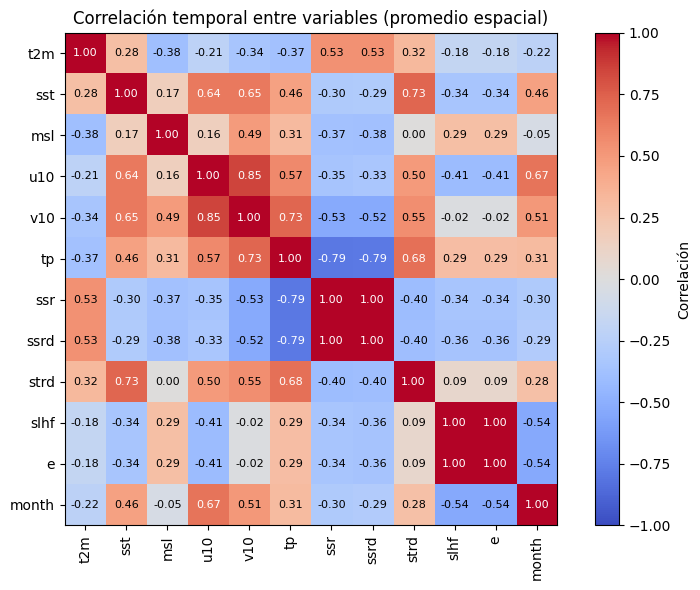

In [59]:
corr_matrix = df_ts.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Correlación temporal entre variables (promedio espacial)")

# Anotar cada celda con su valor
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        valor = corr_matrix.iloc[i, j]
        color = "white" if abs(valor) > 0.6 else "black"  # contraste según intensidad
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.show()

- Bloque radiativo y redundancia temporal

    Se observa una correlación prácticamente perfecta entre las variables radiativas `ssr` y `ssrd`, así como entre los flujos turbulentos `slhf` y `e`. Esta relación indica que dichas variables comparten esencialmente la misma señal temporal a escala mensual, lo que evidencia **redundancia informativa** en el contexto del EDA multivariable. Desde un punto de vista físico, esto es esperable dado que estas variables describen procesos energéticos estrechamente acoplados.

    En consecuencia, para análisis posteriores como reducción de dimensionalidad o modelado estadístico, resulta razonable considerar la selección de una variable representativa por cada par altamente correlacionado.

- Precipitación como variable integradora

    La precipitación total (`tp`) presenta correlaciones positivas moderadas a altas con las componentes del viento (`u10`, `v10`) y con la radiación de onda larga descendente (`strd`), mientras que muestra una fuerte correlación negativa con las variables radiativas de onda corta (`ssr`, `ssrd`). Este patrón sugiere que los meses más lluviosos están asociados a una mayor actividad dinámica y a una reducción de la radiación solar entrante, coherente con la presencia de nubosidad y procesos convectivos.

    En este sentido, `tp` actúa como una **variable integradora**, conectando la dinámica atmosférica con el balance energético del sistema.

- Temperatura y balance energético

    La temperatura a 2 metros (`t2m`) muestra correlaciones positivas con las variables radiativas y negativas con la precipitación y la presión a nivel del mar (`msl`). Este comportamiento indica que los meses más cálidos están asociados a mayores aportes radiativos y condiciones más secas, mientras que los meses más fríos coinciden con una mayor nubosidad y precipitación.

    Este patrón refuerza la interpretación de que la variabilidad térmica mensual está fuertemente controlada por el balance energético superficial.

- Rol modulador de la temperatura superficial del mar

    La temperatura superficial del mar (`sst`) presenta correlaciones positivas con las componentes del viento, la precipitación y la radiación de onda larga, lo que sugiere un papel activo del océano en la modulación de la dinámica atmosférica y de los flujos de energía. Dado el carácter costero de la región analizada, esta relación resulta físicamente consistente y destaca la importancia del acoplamiento océano-atmósfera en la variabilidad climática mensual.

- Dinámica atmosférica

    Las componentes zonal y meridional del viento (`u10` y `v10`) presentan una correlación elevada entre sí, indicando una estructura dinámica coherente. Además, ambas variables se relacionan de forma significativa con la precipitación y con variables energéticas, lo que sugiere que la circulación atmosférica superficial desempeña un papel clave en la organización de los regímenes mensuales.

- Presión a nivel del mar

    La presión a nivel del mar (`msl`) muestra correlaciones moderadas o débiles con la mayoría de las variables, lo que indica que actúa principalmente como una variable moduladora del sistema, más que como un factor dominante de la variabilidad mensual. No obstante, su relación negativa con la temperatura es consistente con la estructura estacional del clima regional.

In [60]:
vars_modelo = ['sst', 'msl', 'u10', 'v10', 'tp', 'slhf', 'ssr', 'strd', 'e']

df_vif = df_ts[vars_modelo].dropna()

vif_data = pd.DataFrame({
    'Variable': vars_modelo,
    'VIF': [variance_inflation_factor(df_vif.values, i)
            for i in range(len(vars_modelo))]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))
print("\nRegla: VIF > 10 → multicolinealidad severa | VIF > 5 → moderada")

Variable          VIF
       e 5.648280e+10
    slhf 3.724788e+09
     sst 1.278397e+06
     msl 8.530610e+05
    strd 6.271728e+04
     ssr 6.693073e+02
      tp 1.518049e+02
     u10 3.344071e+01
     v10 8.717758e+00

Regla: VIF > 10 → multicolinealidad severa | VIF > 5 → moderada


Podemos observar que los valores de VIF complementan lo que se ha visto antes en la matriz de correlaciones:

- Multicolinealidad extrema

    Las variables **e, slhf, sst, msl y strd** presentan valores de VIF **varios órdenes de magnitud mayores que 10**, lo que indica:

    - Dependencia lineal **muy fuerte** entre ellas
    - Información altamente **redundante**
    - Imposibilidad de interpretar coeficientes en modelos lineales

    Estas variables representan procesos **físicamente acoplados** (balance energético, flujos superficie–atmósfera y respuesta sinóptica), por lo que este resultado es **esperado en datasets climáticos** como ERA5.
- Multicolinealidad severa

    Las variables **ssr, tp y u10** muestran VIF elevados (≫10), indicando que:

    - Aportan señal climática relevante
    - Pero **no de forma independiente** respecto a otras variables

    Su uso conjunto en modelos lineales sigue siendo problemático.

- Multicolinealidad moderada

    La variable **v10** presenta un VIF ≈ 9, lo que sugiere:

    - Dependencia moderada con el resto de variables
    - Puede incluirse con **precaución** en análisis lineales